# Université Paul Sabatier
# M1 IAFA - Foundations of Information Retrieval - 2026

Instructors: Lynda Tamine, Karim Radouane and Ahmed Rayane Kebir

---

💡 Consider developing auxiliary scripts and functions that will enable you to reuse recurring commands in this practical work (PW) and future ones. This would help you keeping good code practice and make debugging easier.


### Attention❗ About TP grading:
🚨 *Code questions*: Fill in the missing code in the corresponding sections (commented code gets the best marks).

🚨 *Open questions*: Write your textual answer as a comment in the corresponding cells.

🚨 *Keep your outputs*: **Empty outputs (notebook or non-executed cells) correspond to 0 points**.

---

# TP 1: Language Modeling and Applications for Information Retrieval and Question-Answering

Language modeling is foundamental in natural language processing (NLP) and information retrieval (IR). Basically speaking, it allows trasforming raw textual data  into vector semantics suitable for computational analysis. Vector semantics based on  TF-IDF (Term Frequency-Inverse Document Frequency), word embeddings, and Transformer-based encoders are widely used for this purpose. These vectors are essential as they enable algorithms to process and analyze text quantitatively, supporting natural language understanding tasks like document similarity, clustering, summarization, question-answering, information retrieval, etc.

# The TREC-COVID Dataset

In this PW, we will focus on a real-world dataset called **TREC-COVID dataset**,  that focuses on documents dealing with COVID-19 and a set of related questions. Each question in the dataset is linked to research papers (documents) that may or may not contain the associated correct answers.


# Objectives of the PW

Through this PW, you will:

1. Analyze the structure and content of the TREC-COVID dataset.
2. Implement word-level vector semantics.
3. Explore geometric patterns in word-level vector semantics.
4. Develop document-level vector semantics.
5. Deploy these vector semantics in downstream tasks, such as question-answering and information retrieval.

### Installations and Imports
> 👉 Before starting working with the Transformers-based models, please select ``T4 GPU`` in the menu: ``Runtime/Change runtime type`` and re-run these 2 cells. **Save your work before changing the runtime type**.*

In [1]:
# Some libraries to use later
!pip install numpy==2.0.0 --force-reinstall
!pip install gensim
!pip install scikit-learn matplotlib
!pip install transformers torch
!pip install datasets
!pip install -U sentence-transformers
!pip install -U accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 64.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.4/512.4 kB 12.8 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.2.3
    Uninstalling sentence-transformers-5.2.3:
      Successfully uninstalled sentence-transformers-5.2.3


In [2]:
import datasets
import math
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score

from sklearn.manifold import TSNE
import gensim.downloader as api
from nltk.tokenize import word_tokenize
import nltk

import torch
from transformers import AutoTokenizer, AutoModel
from datasets import Dataset
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

# I. Text Representation: Text pre-processing, vector semantics and similarity.



## 1. Dataset analysis

In this section, we begin by working with a simplified toy version of the TREC-COVID dataset. The data is retrieved from the HuggingFace Datasets library under the name ``jeslev/trec_covid_toyset``, providing a minimal and accessible subset of the full dataset for initial exploration and analysis.

In [3]:
covid_toyset = datasets.load_dataset('jeslev/trec_covid_toyset')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/542 [00:00<?, ?B/s]

data/rel-00000-of-00001.parquet:   0%|          | 0.00/24.8k [00:00<?, ?B/s]

data/nonrel-00000-of-00001.parquet:   0%|          | 0.00/26.1k [00:00<?, ?B/s]

Generating rel split:   0%|          | 0/25 [00:00<?, ? examples/s]

Generating nonrel split:   0%|          | 0/25 [00:00<?, ? examples/s]

We begin by analyzing the dataset to understand its structure and the type of information it contains.

The dataset is divided into two parts: ``rel`` (relevant) and ``nonrel`` (non-relevant) documents to answer a given question. Since both parts share the same structural format, we will focus our analysis on ``rel``.

First, we list all the columns (features) in the dataset to get an overview of the available data.

In [4]:
covid_toyset['rel'].features

{'query-id': Value('int64'),
 'corpus-id': Value('string'),
 'score': Value('int64'),
 'document': Value('string'),
 'text': Value('string')}

####  Question ✍
Describe what each column means according to your interpretation. Which column represents the questions?

**ANSWER**:

**Query-id** id connecting the query to this document that has been recognized as relevant for said query

**corpus-id** id referencing the document

**score** similarity calculated between the query and the document

**document** The content of the document

**text** The content of the query

####  Question ✍
List all the questions and compute the total number of questions.

In [5]:
#### Your code here
list_unique_queries = np.asarray(([x for x in covid_toyset['rel'][:]['text']]+[x for x in covid_toyset['nonrel'][:]['text']]))
list_unique_queries = np.unique(list_unique_queries)
print(len(list_unique_queries))

5


####  Question ✍
Similarly, compute the total number of documents available for each part (``rel`` and ``nonrel``).

Set a variable ``all_docs`` containing both documents present in both parts.

In [6]:
#### Your code here
all_docs = [ x for x in covid_toyset['rel'][:]['document'] ] + [ x for x in covid_toyset['nonrel'][:]['document'] ]
#all_docs = np.asarray(array_docs)

print(len(all_docs))


50


####  Question ✍
Compute the average length of documents in terms of words (and the std dev).

In [7]:
#### Your code here

# Compute the average length and std of documents (# words)
def compute_stats(list_of_sentences):

  l_o_s_length = len(list_of_sentences)
  all_length = []
  all_std = []
  # On calcule la moyenne : mu
  for document in list_of_sentences:
    document = document.split()
    all_length.append(len(document))
  mu = sum(all_length) * (1 / l_o_s_length)
  # On calcule la variance : square root of [ (1/N) times Sigma i=1 to N of (xi - mu)^2 ]
  for document in list_of_sentences:
    document = document.split()
    all_std.append((len(document) - mu)**2)
  std = math.sqrt(sum(all_std) * (1 / l_o_s_length))
  return (round(mu,3), round(std,3))

avg_length_docs, std_docs = compute_stats(all_docs)
print(avg_length_docs, std_docs)

151.62 109.684


####  Question ✍
Compute the average length (and the std dev) of the questions.

**Hint**: Use the functions np.mean and np.std

In [8]:
#### Your code here
# 11 2.6
avg_length_queries, std_queries = compute_stats(list_unique_queries)
print(avg_length_queries, std_queries)


11.0 2.608


####  Question ✍
Furthermore, we evaluate the term distribution of the collection.

Complete the following function. For the given input `tokens`, you need to compute the frequency of each token, and sort them in decreasing order of frequency.

You need to compute both, the list of tokens (`ranks`, list of string) and their frequencies (`frequencies`, list of int). You can use the `Counter` object from Python and the `most_common()` function.

In [9]:
# Term distribution
def compute_term_frequency(list_of_sentences):

  def preprocess_text(text):
    return text.lower().split()

  tokens = []
  for doc in list_of_sentences:
    tokens.extend(preprocess_text(doc))

  # Compute Term Frequencies and
  # Rank Terms and Prepare for Visualization
  tokens_counter = Counter(tokens)

  # liste des ranks
  rank = tokens_counter.most_common()

  frequencies = [ token[1] for token in rank ]

  # liste des frequences
  ranks = [ token[0] for token in rank ]

  # Create Log-Log Plot
  plt.figure(figsize=(8, 6))
  plt.plot(ranks, frequencies, marker='o', linestyle='-', label='Term Distribution')
  plt.xscale('log')
  plt.yscale('log')
  plt.title("Term Distribution TREC-COVID")
  plt.xlabel("Rank (log scale)")
  plt.ylabel("Frequency (log scale)")
  plt.grid(True, which="both", linestyle="--", linewidth=0.5)
  plt.legend()
  plt.show()

In [10]:
# Our term distribution inspection consists of documents and questions,
# we keep trace of an index to identify them.
doc_2_id = {}
my_mini_corpus = []
for _id, single_doc in enumerate(all_docs + list(list_unique_queries)):
  my_mini_corpus.append(single_doc)
  doc_2_id[single_doc] = _id


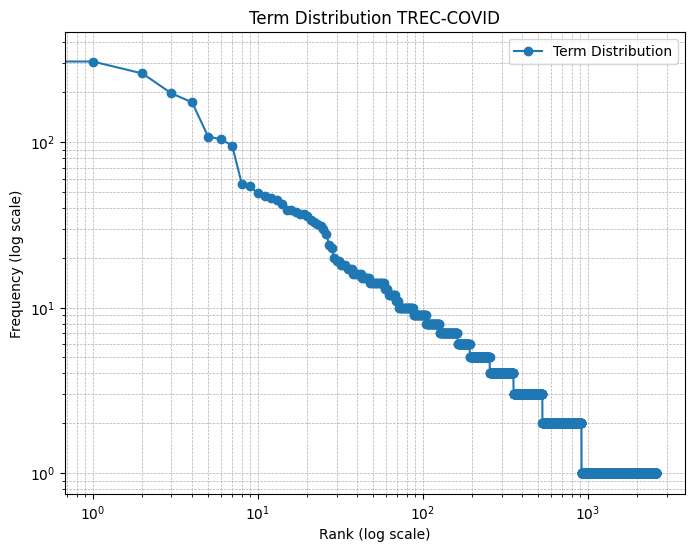

In [11]:
compute_term_frequency( my_mini_corpus )

###  Question ✍
Analyze the figure and provide a possible interpretation

**ANSWER**: This figure shows that token frequency is linear. But most importantly that tokens (words) that have a frequency between 10^1 and 10^2 are clustered. All the other words that are very frequent or very infrequent are less numerous. Most words are clustered and thus it is relatively easy to identify frequent words since there are less. This is a known phenomenon of different languages, this is one of the reasons Neural Networks function effectively and training them actually works. It's always the same words that have the same frequencies.

## 2. Word-level vector semantics

Text can be represented as vectors at various levels of granularity. In this section, we focus on implementing and working with word-level vector semantics, exploring both sparse and dense approaches (refer to the class resources for more details).

We will examine three key methods for representing vector semantics: TF-IDF, Word Embeddings, and Transformers (BERT)-based representations.


 ### a) TF-IDF (Sparse vector semantics)

The Term Frequency-Inverse Document Frequency (TF-IDF) based vector semantics  transforms text into vectors by quantifying the importance of terms within a a document and corpus.

Using the ``TfidfVectorizer`` from the Sklearn library, we can easily implement this type of vectors. The input to the vectorizer is the corpus (a collection of documents and questions as textual information). The output is a matrix where each row corresponds to a document, and each column represents a unique term in the corpus, collectively known as the ``vocabulary``. The matrix values indicate the TF-IDF score for each term in a document.

To represent a specific word numerically, we extract the corresponding column from the matrix. Below, we demonstrate how to implement this method using the toyset and obtain a single word's representation:



In [12]:
def get_tfidf_representations(my_corpus, use_idf=True, norm='l2'):
  """return: tuple of vectorizer and tfidf_matrix
   which contain information about corpus and tfidf matrix generated
  """
  # TFIDFVectorizer equivalent to CountVectorizer followed by TfidfTransfromer
  vectorizer = TfidfVectorizer(use_idf=use_idf, norm=norm )
  # Fit and Transform the Corpus
  tfidf_matrix = vectorizer.fit_transform(my_corpus)
  return vectorizer, tfidf_matrix

def get_tfidf_word(tfidf_matrix, word_to_index, word):
  if word not in word_to_index:
    raise ValueError("Not in the vocabulary.")
  return tfidf_matrix[:, word_to_index[word]].toarray().flatten()

def plot_single_points(all_words, word_to_index, vis_2d):
  # Plot representation of each word
  plt.figure(figsize=(12, 8))
  for word in all_words:
      i = word_to_index[word]
      x, y = vis_2d[i, 0], vis_2d[i, 1]
      plt.scatter(x, y, color='blue', s=50)
      plt.text(x + 0.1, y + 0.1, word, fontsize=10)

  plt.title("Word Vector Representations", fontsize=14)
  plt.xlabel("t-SNE X", fontsize=12)
  plt.ylabel("t-SNE Y", fontsize=12)
  plt.grid(True)
  plt.show()

# New addition to complete cell 61 (Document-level vector question)
def represent_tfidf_vector(vectorizer, tfidf_matrix, nb_words=50):
  # We compute the vocab to the use it
  vocab = vectorizer.get_feature_names_out()
  # We transform the tf-idf matrix to 2D to plot
  tsne_tfidf = TSNE(n_components=2, random_state=42, perplexity=5, init='random', learning_rate=200)
  tfidf_2d = tsne_tfidf.fit_transform(tfidf_matrix.T.toarray())
  # We index the words of vocab to plot them
  word_to_index = {word: i for i, word in enumerate(vocab)}
  plot_single_points( vocab[:30], word_to_index, tfidf_2d )
  # we return the vocab so that we can reuse it
  return vocab


In [13]:
tdidf_representations, tfidf_matrix = get_tfidf_representations(my_mini_corpus)
vocab = tdidf_representations.get_feature_names_out()
print(vocab)

['000' '001456' '002' ... 'zoonotic' 'β1b' 'μl']


We visualize the TF-IDF Matrix. We observe that we have as many rows as documents in our corpus. In the column names, we observe the vocabulary (words) considered by this method.

In [14]:
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tdidf_representations.get_feature_names_out())
# Display the TF-IDF Representation
print("TF-IDF Document Representation:")
print(tfidf_df)

TF-IDF Document Representation:
         000  001456       002       008       009        01       017  \
0   0.000000   0.000  0.000000  0.000000  0.000000  0.000000  0.000000   
1   0.000000   0.000  0.000000  0.000000  0.000000  0.000000  0.000000   
2   0.000000   0.000  0.000000  0.000000  0.000000  0.000000  0.000000   
3   0.000000   0.000  0.000000  0.050279  0.000000  0.000000  0.000000   
4   0.000000   0.000  0.000000  0.000000  0.000000  0.000000  0.000000   
5   0.000000   0.000  0.000000  0.000000  0.000000  0.000000  0.000000   
6   0.000000   0.046  0.000000  0.000000  0.000000  0.000000  0.000000   
7   0.000000   0.000  0.000000  0.000000  0.000000  0.000000  0.000000   
8   0.000000   0.000  0.000000  0.000000  0.000000  0.000000  0.000000   
9   0.000000   0.000  0.000000  0.000000  0.000000  0.000000  0.000000   
10  0.000000   0.000  0.000000  0.000000  0.000000  0.000000  0.000000   
11  0.000000   0.000  0.000000  0.000000  0.000000  0.000000  0.000000   
12  0.

The vector semantics of words can be visualized in a 2D graph using dimensionality reduction techniques. Each word is mapped to a specific point in the space, providing a visual representation of their relationships and distribution.

We obtain these representations with the following lines using the ``TSNE`` method. For our example, we examine 4 words: ``masking``, ``face``, ``gloves``, ``hands``.

Please note that ``masking`` refers to ``mask``. However, in our available vocabulary from TF-IDF, ``mask`` does not exist.

In [15]:
# Perform t-SNE to reduce dimensions to 2D from TD-IDF matrix
tsne_tfidf = TSNE(n_components=2, random_state=42, perplexity=5, init='random', learning_rate=200)
tfidf_2d = tsne_tfidf.fit_transform(tfidf_matrix.T.toarray())  # Transpose to work with word vectors
# Get vocabulary (words and their indices)
word_to_index = {word: i for i, word in enumerate(vocab)}

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7a3b040e1080>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


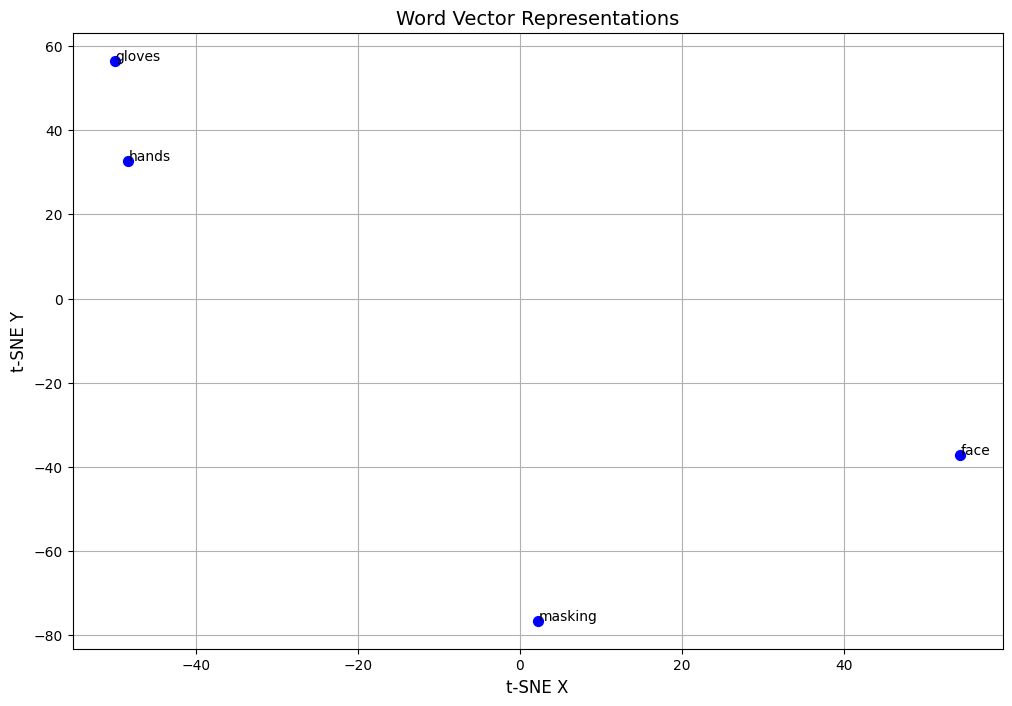

In [16]:
all_words  = ["masking", "face", "gloves", "hands"]
plot_single_points(all_words, word_to_index, tfidf_2d)

####  Question ✍

Implement two other variants of TF-IDF (as presented in class). Then, visualize the representations of the same words. Do they change? Why?


**Hint:**
- For one variantion you can set the parameter ``use_idf``, to omit IDF values.
- For a second variation, you can use ``norm=None`` to avoid normalization, and use the max tf instead (to implement the TF_MAX version)

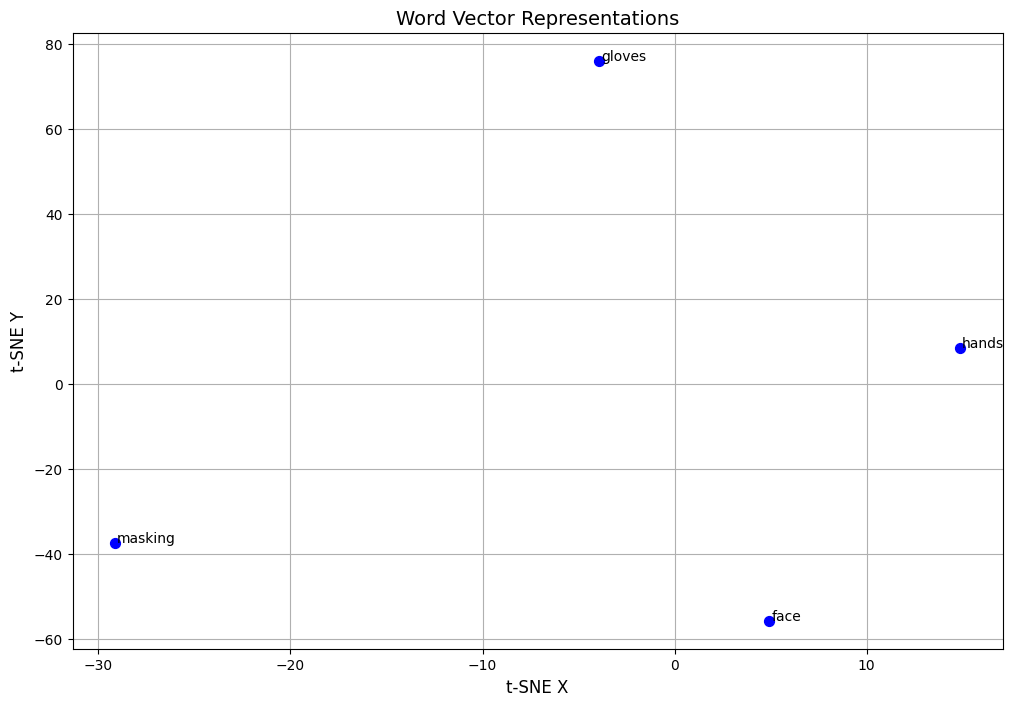

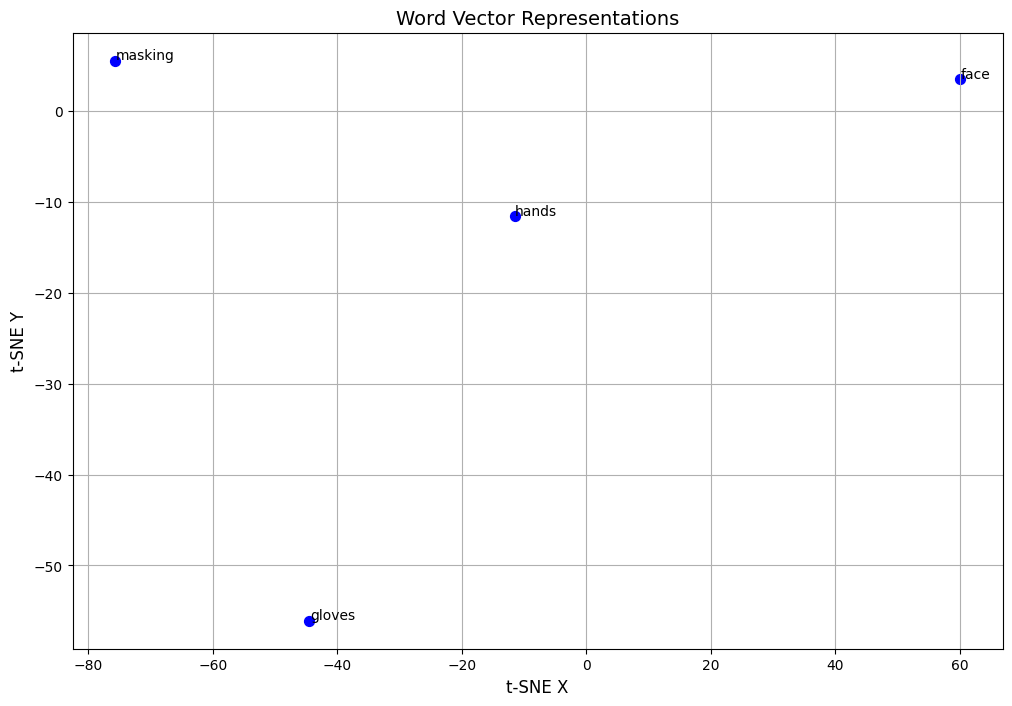

In [17]:
#### TF-IDF score variation 1
tdidf_representations_var_1, tfidf_matrix_var_1 = get_tfidf_representations(my_mini_corpus, use_idf=False)
vocab_var_1 = tdidf_representations_var_1.get_feature_names_out()

# Perform t-SNE to reduce dimensions to 2D from TD-IDF matrix
tfidf_2d = tsne_tfidf.fit_transform(tfidf_matrix_var_1.T.toarray())  # Transpose to work with word vectors

plot_single_points(all_words, word_to_index, tfidf_2d)



### TF-IDF score variation 2
tfidf_representations_var_2, tfidf_matrix_var_2 = get_tfidf_representations(my_mini_corpus, norm=None)
vocab_var_2 = tfidf_representations_var_2.get_feature_names_out()
# Perform t-SNE to reduce dimensions to 2D from TD-IDF matrix
tfidf_2d = tsne_tfidf.fit_transform(tfidf_matrix_var_2.T.toarray())  # Transpose to work with word vectors

plot_single_points( all_words, word_to_index, tfidf_2d )




**Answer**:
Term Frequency: more frequent is a word in a document, more it is important

Inverse Document Frequency: more rare is the word in the collection, more it is important

We can see that when we compute the versions of tf-idf without normalization and wih idf set to false the vectors gloves and hands are no longer formed in a cluster. All different vectors are distanced and we can no longer clearly see a similarity between the selected words


### b) Word-embeddings (dense vector semantics)

A dense representation of vector semantics is **word embeddings**, which leverages neural networks to capture deep meanings and relationships between words. These embeddings represent each word as a vector in a continuous space, enabling a deeper understanding of linguistic patterns and relationships.

Pre-trained word vectors or static embeddings can be downloaded and used directly, simplifying implementation. For example, the following code demonstrates how to download pre-trained Word2Vec embeddings, such as those trained on the Google News dataset:



In [18]:
def get_word_embeddings():
  # Download and load a pre-trained Word2Vec model
  nltk.download('punkt_tab')
  model = api.load("word2vec-google-news-300")
  return model

def get_w2v_vector(word, model):
  if word in model:
    return model[word]
  else:
    return "Not in vocabulary"

In [19]:
w2v_model = get_word_embeddings()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


[==================================================] 100.0% 1662.8/1662.8MB downloaded


####  Question ✍
Obtain the vocabulary of these models (you can use the `key_to_index` attribute).

Compare the vocabulary size between TF-IDF and Word2Vec. Explain why there are these differences

In [20]:
### Your code here

# We list the first 10 words
# The size of the dataset can be obtained by simply using len(w2v_model)

for index, word in enumerate(w2v_model.index_to_key):
    if index == 10:
        break
    print(f"word #{index}/{len(w2v_model.index_to_key)} is {word}")

print(len(w2v_model))
print(len(vocab))

word #0/3000000 is </s>
word #1/3000000 is in
word #2/3000000 is for
word #3/3000000 is that
word #4/3000000 is is
word #5/3000000 is on
word #6/3000000 is ##
word #7/3000000 is The
word #8/3000000 is with
word #9/3000000 is said
3000000
2071


**Answer:**: The vocabulary size difference is explained by the size of the dataset. The dataset that w2v_model is using is a much larger that the size of the toy dataset that we were using to calculate the TF-IDF matrix. They are not comparable

For fair comparison, we will keep the vocabulary from TF-IDF into Word2Vec.

This code will filter only the words existing on TF-IDF from Word2Vec

In [21]:
emb_w2v = []
vocab_w2v = []
for word in vocab:
  if word in w2v_model:
    emb_w2v.append(w2v_model[word])
    vocab_w2v.append(word)

w2v_to_index = {}
for i, word in enumerate(vocab_w2v):
  w2v_to_index[word] = i

In [22]:
# Perform t-SNE to reduce dimensions to 2D
tsne_w2v = TSNE(perplexity=15, n_components=2, init='pca', n_iter=2000, random_state=42)
w2v_2d = tsne_w2v.fit_transform(np.array(emb_w2v))  # Transpose to work with word vectors

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Similar to the previous method, we visualize the representations of the selected words using a 2D plot.

This visualization reveals that the model provides distinct representations and alters the relative distances between points, reflecting the semantic relationships captured by the embeddings.

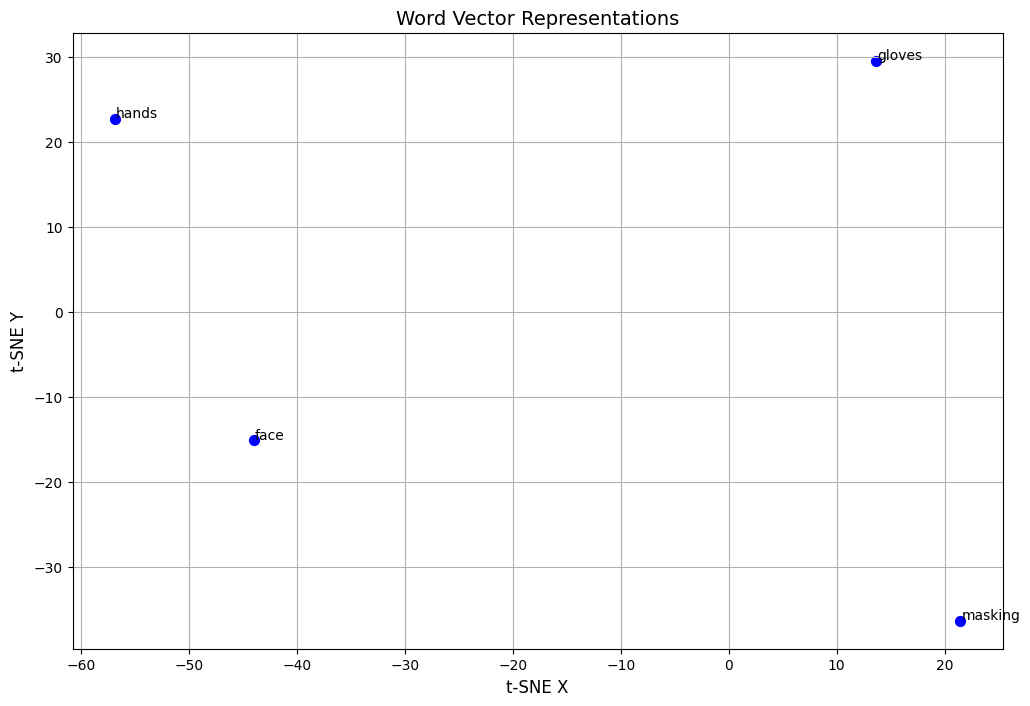

In [23]:
all_words  = ["masking", "face", "gloves", "hands"]
plot_single_points(all_words, w2v_to_index, w2v_2d)

### c) Transformers-based representation (BERT)


Another powerful language model for representing words and sentences in context is the Transformer-based encoder, such as BERT (Bidirectional Encoder Representations from Transformers). Unlike pre-trained word embeddings like Word2Vec, BERT employs a deep learning model based on the Transformer architecture to generate contextual embeddings.

For this task, we will use the pre-trained Bi-Encoder model, specifically the ``all-MiniLM-L6-v2``, which is available on the HuggingFace hub. Transformer-based models introduce a special token called the [CLS] token (Classification token). This token is appended to the beginning of every input, and the vector corresponding to this token, after processing through the BERT model, captures the contextualized information of the entire input sequence (see your course).

The following code loads the model from HuggingFace. We also use the ``encode`` method from the ``SentenceTransformer`` library to obtain the model representations directly.

In [24]:
model_name = 'sentence-transformers/all-MiniLM-L6-v2'  # You can use any model available
enc_model = SentenceTransformer(model_name)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [25]:
# On prend l'encodage du model en utilisant le vocabulaire du toyset.
emb_enc = enc_model.encode(vocab)

# On passe de numpy array a un array normal
vocab_enc = [word for word in vocab]


enc_to_index = {}
for i, word in enumerate(vocab_enc):
  enc_to_index[word] = i


####  Question ✍
Similarly, compute the 2D-representations

In [26]:
# Perform t-SNE to reduce dimensions to 2D
# Comme expliqué dans la documentation, il est conseillé d'utiliser la méthode de reduction
# PCA pour des vecteurs denses
tsne_enc = TSNE( perplexity=15, n_components=2, init='pca', n_iter=2000, random_state=42 )
enc_2d = tsne_enc.fit_transform(np.array(emb_enc))  # Transpose to work with word vectors

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


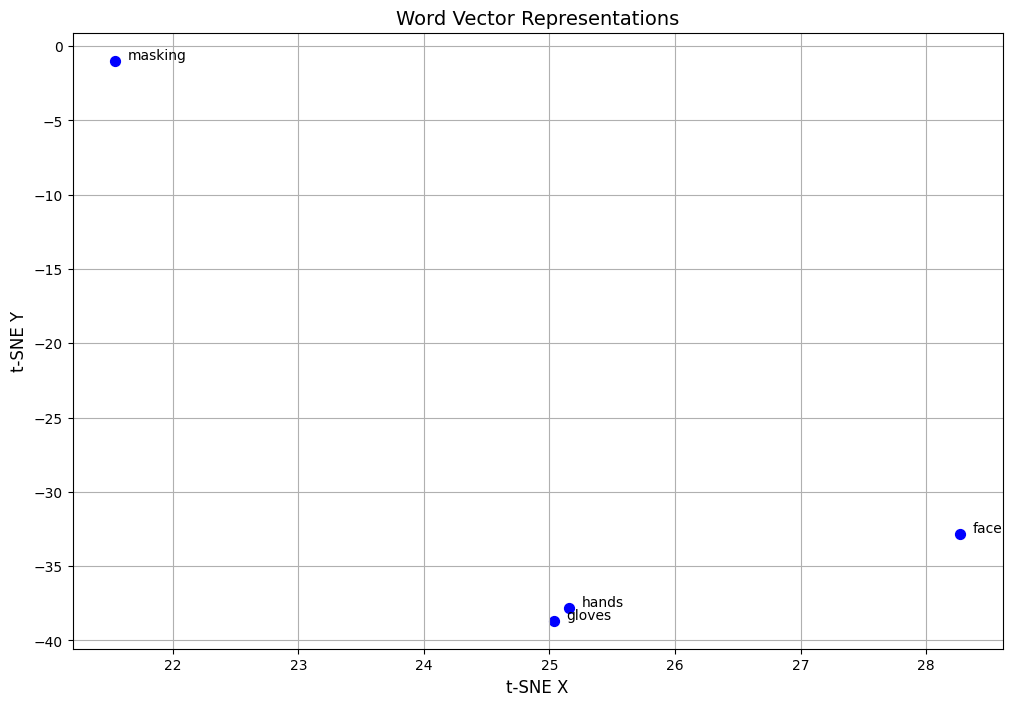

In [27]:
all_words  = ["masking", "face", "gloves", "hands"]
plot_single_points(all_words, enc_to_index, enc_2d)

####  Question ✍
Analyze the 3 graphic representations from different methods. Why do different methods have different representations? Which one is the best and why?

**Answer**: If the question is to analyze the 3 in reality 4 graphics that where obtained:
- computing the TF-IDF using TF = n(t,d) and idf(t) = log [ n / df(t) ] + 1
- computing the TF-IDF with idf(t) = 1 setting use_idf to false.
- computing the TF-IDF without normalizing.
- using a Transformer who encoded our vocab

The better one is the last graph. That was actually the only one that kept the semantic meaning of the words and thus allowed to create more meaningfull clusters. The words "gloves" and "hands" clustered and closeby to "face". They all are close together when compared to the word distance between "masking" and the rest of the words, this can be explained because this word doesn't appear in the vocabulary.

## 2. Geometric patterns of vector semantics (Geometric analogies)

We will explore the spatial relationships between word representations in a a geometric space. By analyzing these geometric patterns, we can gain insights into how different words are positioned relative to each other, revealing semantic similarities and distances. This exploration helps us understand the structure of the embeddings and their ability to capture meaning and context. We will visualize these semantic relationships using dimensionality reduction techniques used before.

Our analysis involves given three words (for example: ``masking``, ``face``, ``gloves``), where we aim to satisfy the equation:
> ``vector(masking) - vector(face) = vector(gloves) - vector(?)``

This equation seeks to capture the relationship between ``masking`` and ``face``, and infer the corresponding word for ``gloves`` (expected output: ``hands``), based on the shared contextual relationship between body position and usage.

The following function, ``perform_analogy``, takes as input three words and their corresponding vector representations, along with a matrix containing all the vectors from the vocabulary of a specific method (``matrix_vecs``). The function computes the vector closest to the expected output, by calculating the vector:
> ``vector(x) = vector(face) - vector(masking) + vector(gloves)``

and identifying the closest match.


####  Question ✍
Complete the function. The missing part is to compute the most similar words, excluding the input words, from the variable `similarities`.

You should print the `top_k` most similar words.

In [28]:

# Function to compute analogies
def perform_analogy(vocab, all_words, all_vecs, matrix_vecs, top_k=3):
    """
    word_a is to word_b as word_c is to ?
    Formula: vector(word_d) ≈ vector(word_b) - vector(word_a) + vector(word_c)
    """
    word_a, word_b, word_c = all_words
    vec_a, vec_b, vec_c = all_vecs

    # Compute the analogy vector
    analogy_vector = vec_b - vec_a + vec_c
    # Compute cosine similarity with all other words
    similarities = cosine_similarity(analogy_vector.reshape(1, -1), matrix_vecs).flatten()

    # Find the most similar word (excluding the input words)
    #### Your code here
    top_k_words = []
    array_all_words = [ word_a, word_b, word_c ]
    # On veut afficher les top_k plus proches mots de notre analogy vector
    for sorted_index in np.flip( np.argsort( similarities, axis=0 )[-top_k:] ):
      if(vocab[sorted_index] not in array_all_words ): top_k_words.append( vocab[sorted_index] )

    # On affiche en utilisant tfidf_2d qui a déjà été
    # calculée dans une cellule précédente
    plot_single_points(top_k_words + array_all_words, word_to_index, tfidf_2d)
    # On retourne le meilleur et les k meilleurs (tuple)
    return top_k_words[0], top_k_words


We compute the candidates for our analogy using the **TF-IDF** method

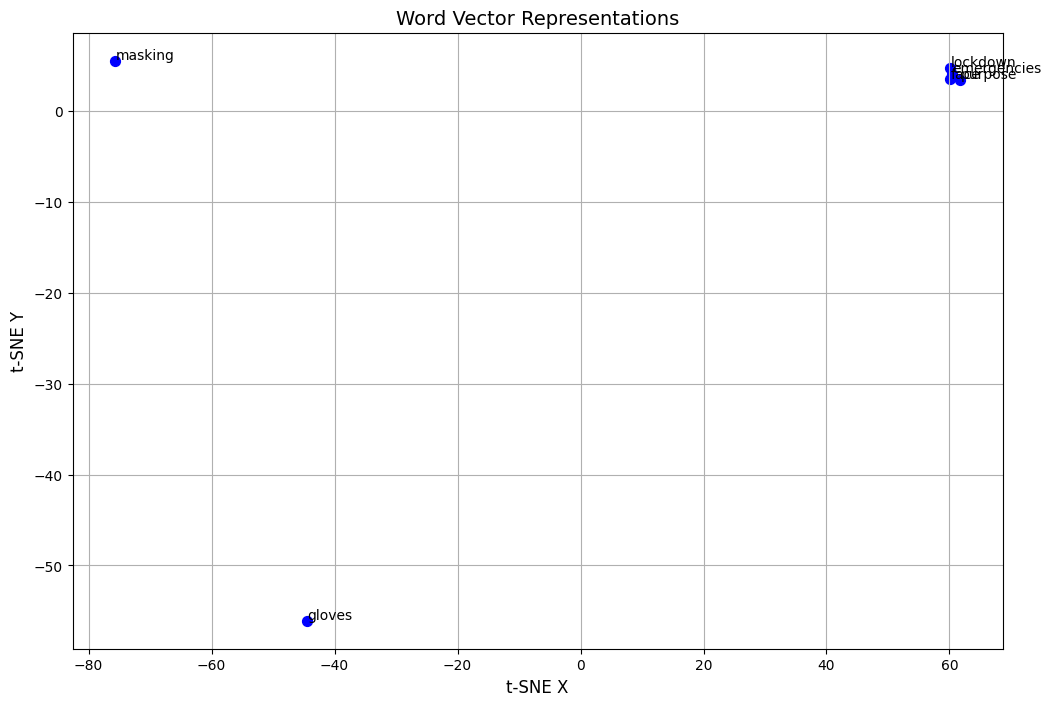

('lockdown', ['lockdown', 'emergencies', 'purpose'])

In [29]:
# vector(word_d) - vector(word_c) ≈ vector(word_b) - vector(word_a)
# TF-IDF
all_words = "masking", "face", "gloves"
all_vecs = []
for word in all_words:
  all_vecs.append(get_tfidf_word(tfidf_matrix, word_to_index, word))

matrix_vecs = tfidf_matrix.T # All embeddings


perform_analogy(vocab, all_words, all_vecs, matrix_vecs, top_k=3)

Similarly, we compute the candidate using the **Word Embeddings** previously computed

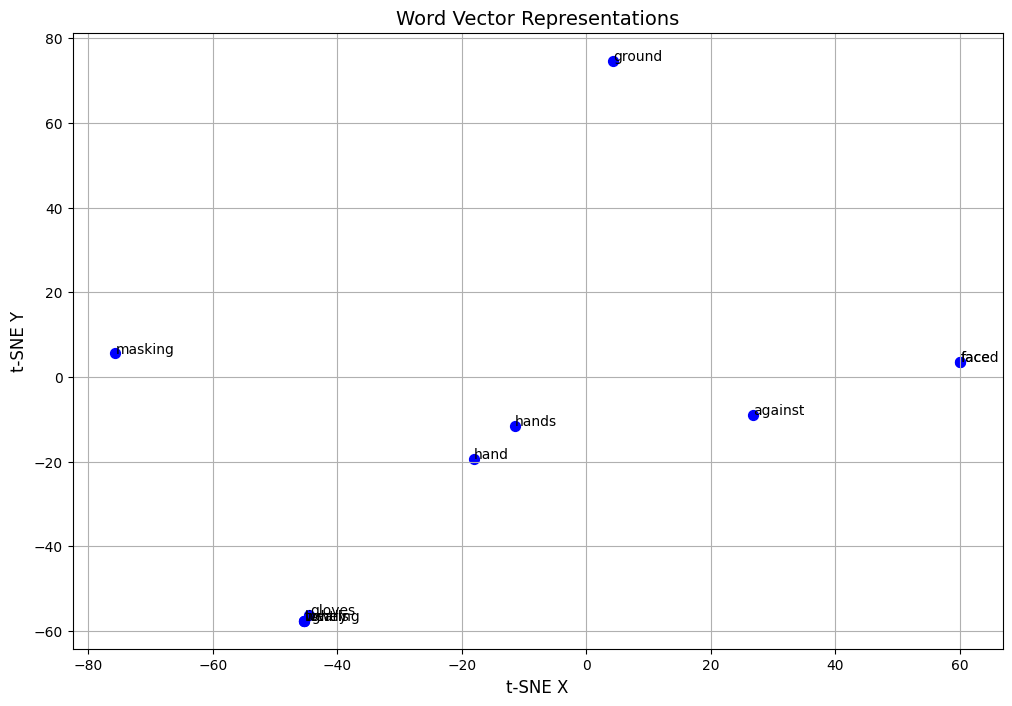

('hands',
 ['hands',
  'towels',
  'faced',
  'hand',
  'wearing',
  'against',
  'lightly',
  'ground'])

In [30]:
# Word embeddings
all_words = "masking", "face", "gloves"
all_vecs = []
for word in all_words:
  all_vecs.append(get_w2v_vector(word, w2v_model))
# All embeddings
matrix_vecs = emb_w2v #np.array([ w2v_model[word] for word in vocab])
perform_analogy(vocab_w2v, all_words, all_vecs, matrix_vecs, top_k=10)

Lastly, we do the same with the **Transformers-based** methods

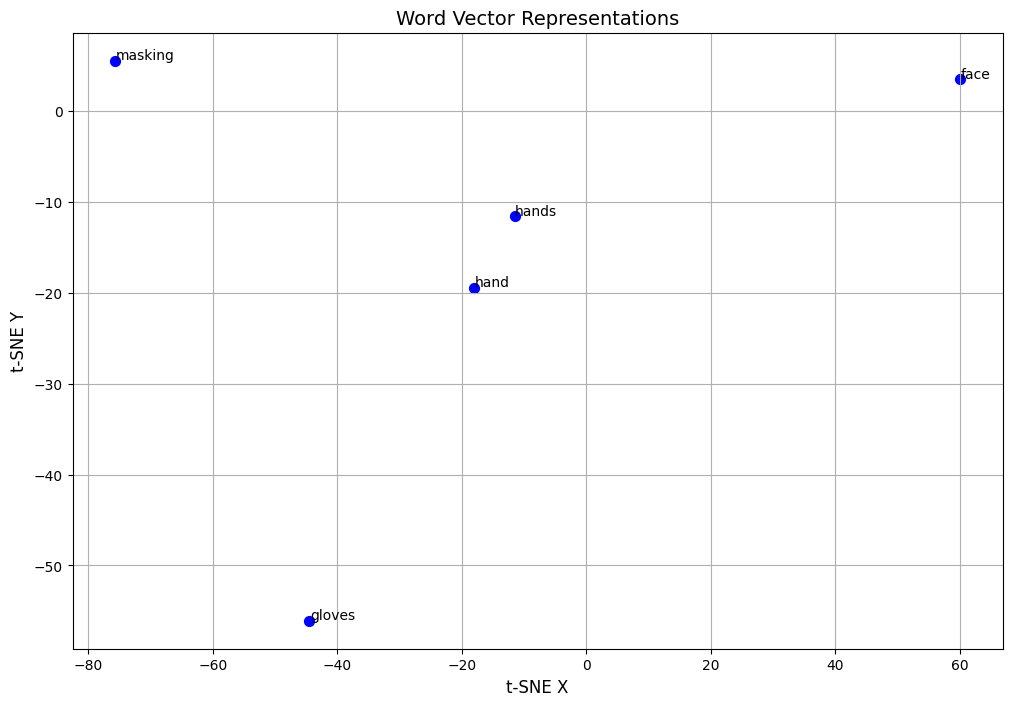

('hands', ['hands', 'hand'])

In [31]:
# Encoder
all_words = "masking", "face", "gloves"
all_vecs = enc_model.encode(all_words)
# All embeddings
matrix_vecs = emb_enc
perform_analogy(vocab_enc, all_words, all_vecs, matrix_vecs, top_k=3)

####  Question ✍
Compute the top-5 closest word that satisfy the analogy for each method:

 "patient"-"hospital" = "children"- "?"

 > Ideally, we can imply a relation of 'goes to', 'belongs to'. A possible value for "?" is "school" or similar words.

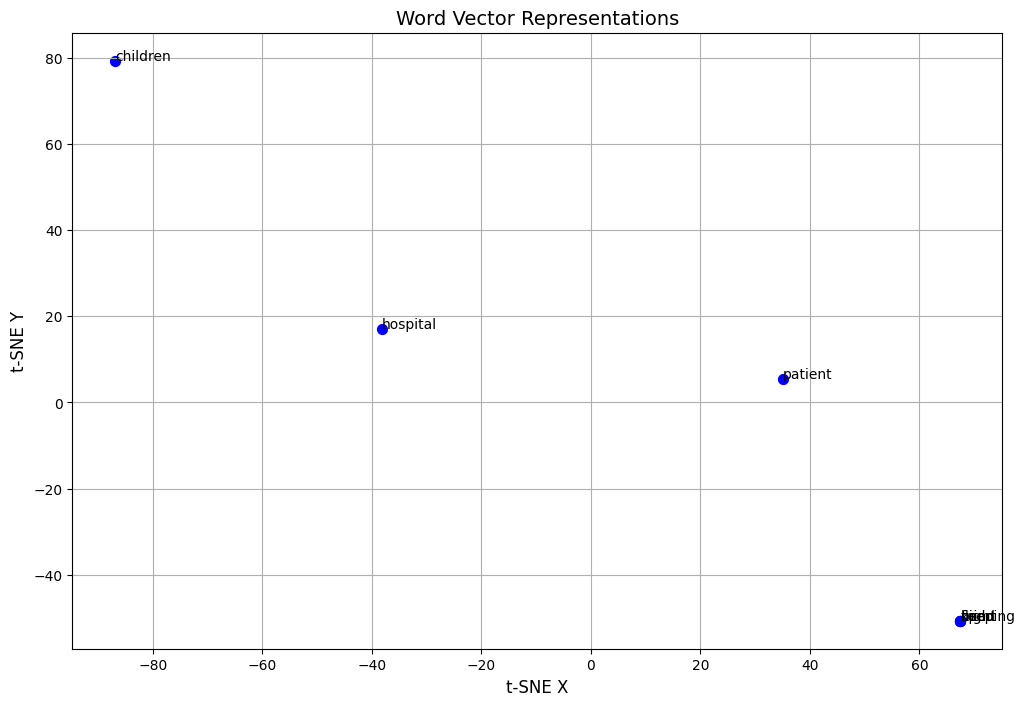

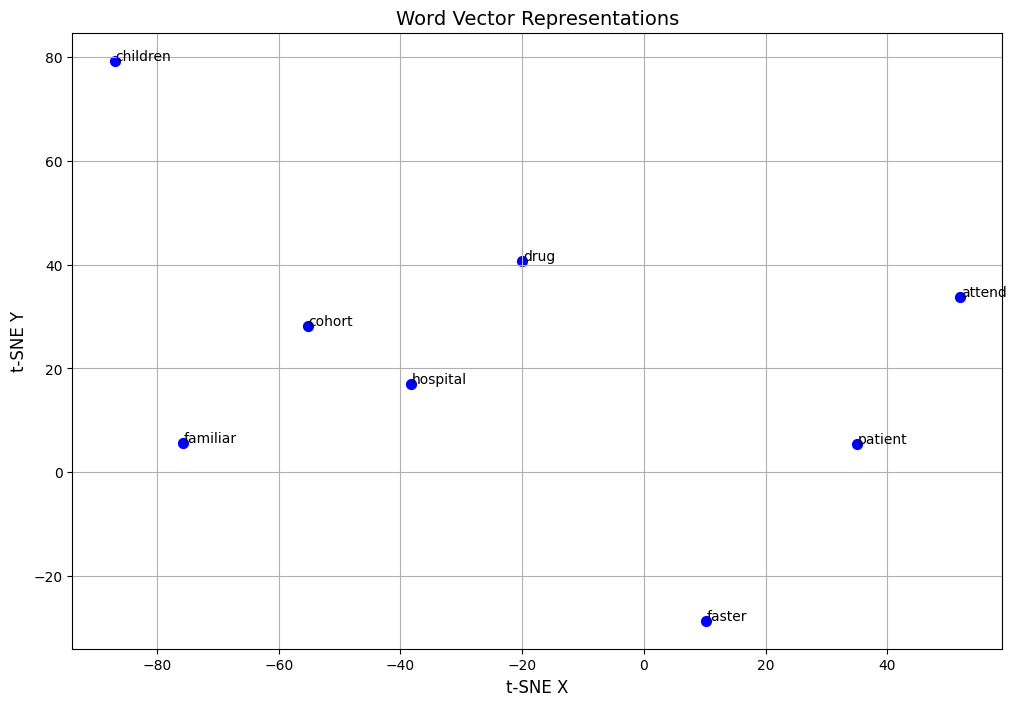

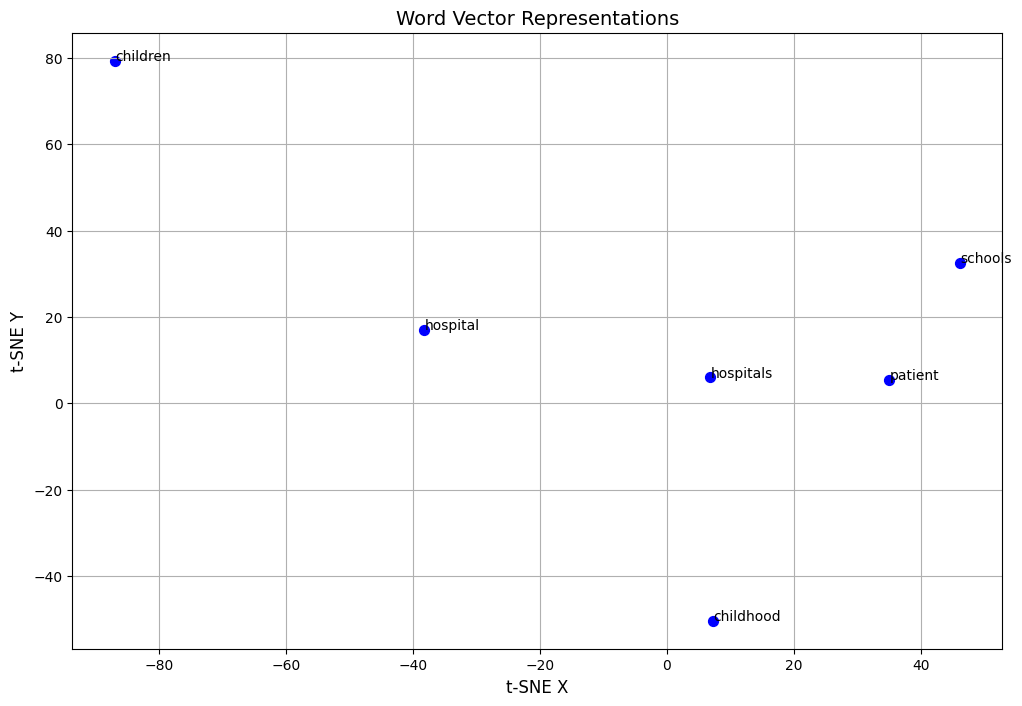

TF-IDF: open
Embeddings: attend
Transformer: schools
TF-IDF Nearest: ['open', 'keeping', 'flight', 'mind']
Embedding Nearest:  ['attend', 'familiar', 'cohort', 'drug', 'faster']
Transformer Nearest ['schools', 'hospitals', 'childhood']


In [32]:
#### Your code here

all_words = "patient", "hospital", "children"

# TF-IDF
def compute_tfidf_analogy(all_words):

  all_vecs = []
  for word in all_words:
    all_vecs.append(get_tfidf_word(tfidf_matrix, word_to_index, word))

  matrix_vecs = tfidf_matrix.T

  return perform_analogy(vocab, all_words, all_vecs, matrix_vecs, top_k=5)
# Word Embedding
def compute_embedding_analogy(all_words):
  all_vecs = []
  for word in all_words:
    all_vecs.append( get_w2v_vector(word, w2v_model) )

  matrix_vecs = emb_w2v
  return perform_analogy(vocab, all_words, all_vecs, matrix_vecs, top_k=5)

# Encoders
def compute_transformer_analogy(all_words):
  all_vecs = enc_model.encode( all_words )
  matrix_vecs = emb_enc
  return perform_analogy(vocab, all_words, all_vecs, matrix_vecs, top_k=5)


best_word_tfidf, best_k_words_tfidf = compute_tfidf_analogy(all_words)
best_word_emb, best_k_words_emb = compute_embedding_analogy(all_words)
best_word_trans, best_k_words_trans = compute_transformer_analogy(all_words)

print(f"TF-IDF: {best_word_tfidf}\nEmbeddings: {best_word_emb}\nTransformer: {best_word_trans}")
print(f"TF-IDF Nearest: {best_k_words_tfidf}\nEmbedding Nearest:  {best_k_words_emb}\nTransformer Nearest {best_k_words_trans}")


####  Question ✍

Propose another analogy and compute the possible value for the different methods.


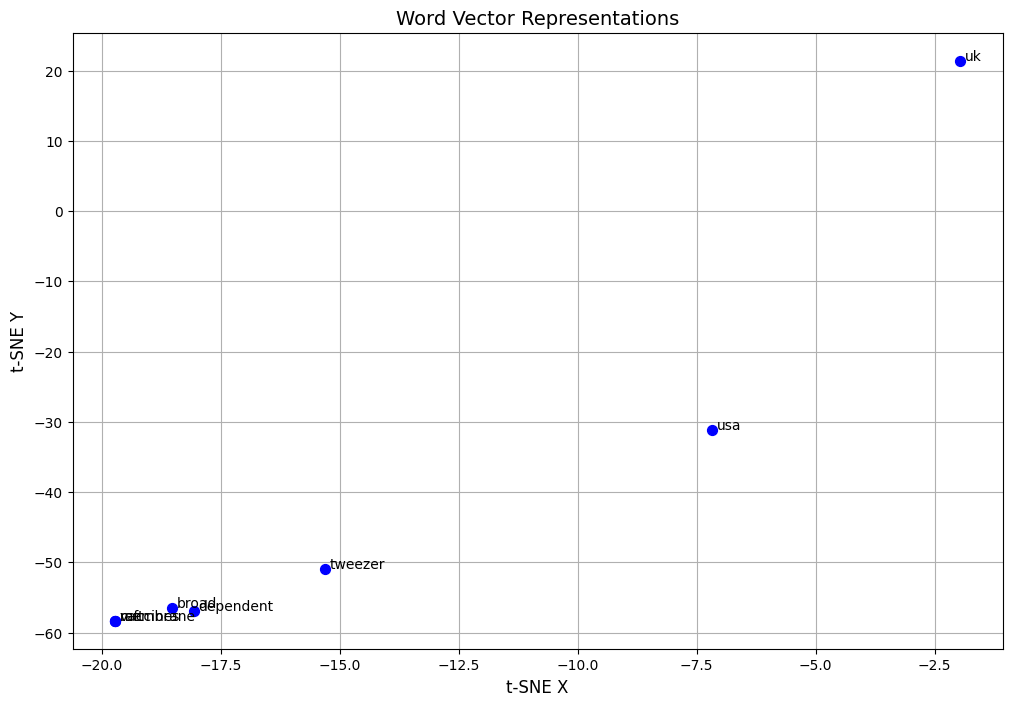

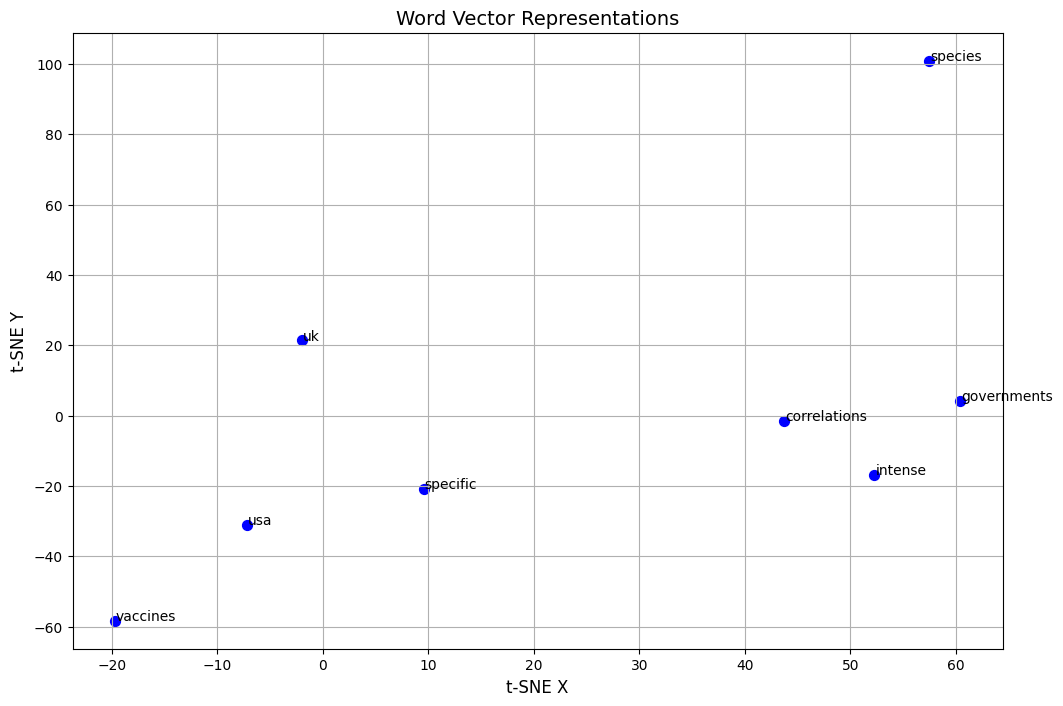

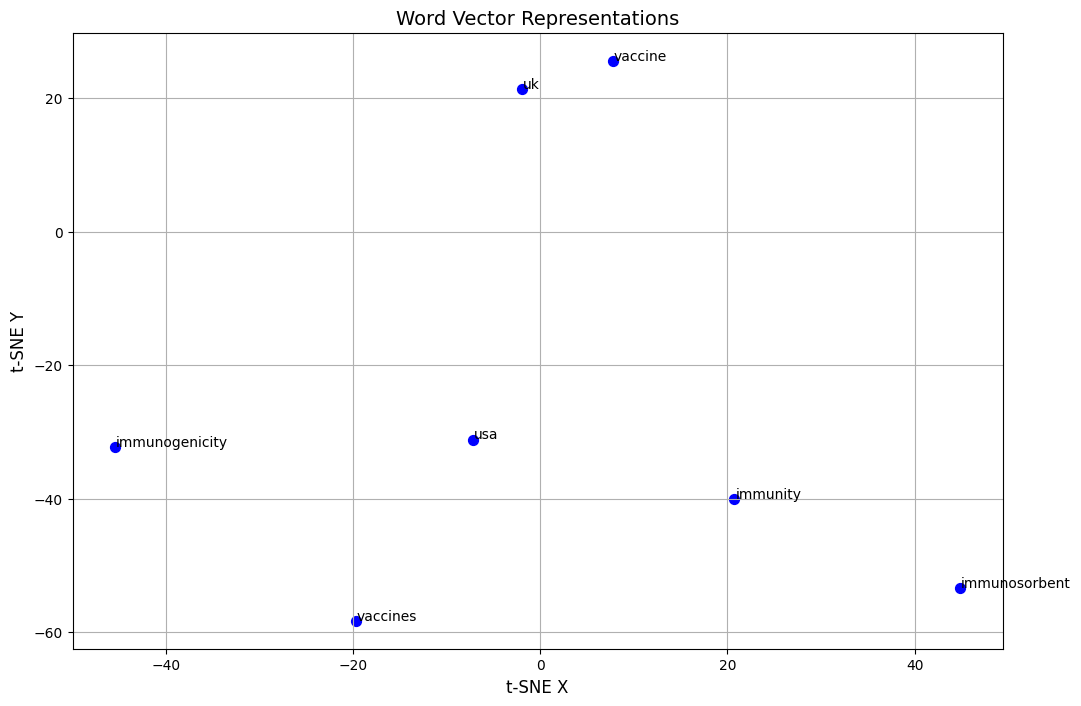

TF-IDF: raft
Embeddings: specific
Transformer: vaccine
TF-IDF Nearest: ['raft', 'tweezer', 'dependent', 'broad', 'membrane']
Embedding Nearest:  ['specific', 'species', 'correlations', 'intense', 'governments']
Transformer Nearest ['vaccine', 'immunity', 'immunogenicity', 'immunosorbent']


In [33]:
#### Your code here
# On pourrait aussi utiliser l'analogie usa - vaccines = uk - ?
# On cherche dans l'ideal à trouver Aunt.
all_words = "uk", "vaccines", "usa"

best_word_tfidf, best_k_words_tfidf = compute_tfidf_analogy(all_words)
best_word_emb, best_k_words_emb = compute_embedding_analogy(all_words)
best_word_trans, best_k_words_trans = compute_transformer_analogy(all_words)

print(f"TF-IDF: {best_word_tfidf}\nEmbeddings: {best_word_emb}\nTransformer: {best_word_trans}")
print(f"TF-IDF Nearest: {best_k_words_tfidf}\nEmbedding Nearest:  {best_k_words_emb}\nTransformer Nearest {best_k_words_trans}")



## 3. Document-level vector semantics

The previous vector semantics capture text at a word level. To obtain document-level vector semantics, we will adapt each method as follows:

1. TF-IDF: We directly use the vector representation of each document (i.e., each row in the TF-IDF matrix), instead of individual words (columns).
2. Word embeddings: We compute a global document representation by averaging the word embeddings for all the words in the document.
3. Transformer-based encoder: This method computes sentence-level representations directly from the model, capturing the context of the entire document.


In the following section, we will implement the functions to compute these document-level vector semantics based on each method.

First, we manually choose two questions and their corresponding relevant and non-relevant documents to visualize them.

In [34]:
# Manually chosen IDs (1 question, 1 doc rel,  1 doc non_rel)
doc_rel_1, doc_nrel_1, q_1 = 0, 25, 52
doc_rel_2, doc_nrel_2, q_2 = 12, 35, 51

In [35]:
# Perform visualization
def plot_doc_points(q1, q2, vis_2d):
    # Plot representation of each word
    plt.figure(figsize=(12, 8))
    x, y = vis_2d[q1[0], 0], vis_2d[q1[0], 1]
    plt.scatter(x, y, color='blue', s=50)
    plt.text(x + 0.1, y + 0.1, "q1", fontsize=10)

    x, y = vis_2d[q1[1], 0], vis_2d[q1[1], 1]
    plt.scatter(x, y, color='green', s=50)
    plt.text(x + 0.1, y + 0.1, "doc_r1", fontsize=10)

    x, y = vis_2d[q1[2], 0], vis_2d[q1[2], 1]
    plt.scatter(x, y, color='red', s=50)
    plt.text(x + 0.1, y + 0.1, "doc_nr1", fontsize=10)

    x, y = vis_2d[q2[0], 0], vis_2d[q2[0], 1]
    plt.scatter(x, y, color='blue', s=50)
    plt.text(x + 0.1, y + 0.1, "q2", fontsize=10)

    x, y = vis_2d[q2[1], 0], vis_2d[q2[1], 1]
    plt.scatter(x, y, color='green', s=50)
    plt.text(x + 0.1, y + 0.1, "doc_r2", fontsize=10)

    x, y = vis_2d[q2[2], 0], vis_2d[q2[2], 1]
    plt.scatter(x, y, color='red', s=50)
    plt.text(x + 0.1, y + 0.1, "doc_nr2", fontsize=10)


    plt.title("Documents Representations", fontsize=14)
    plt.xlabel("t-SNE X", fontsize=12)
    plt.ylabel("t-SNE Y", fontsize=12)
    plt.grid(True)
    plt.show()

#### a) TF-IDF

We extract the corresponding vector representations for each element and plot them into 2D

In [36]:
# TD-IDF, we obtain the row
tf_idf_v1 = tfidf_matrix.toarray()[doc_rel_1]
tf_idf_v2 = tfidf_matrix.toarray()[doc_nrel_1]
tf_idf_v3 = tfidf_matrix.toarray()[q_1]

tf_idf_v4 = tfidf_matrix.toarray()[doc_rel_2]
tf_idf_v5 = tfidf_matrix.toarray()[doc_nrel_2]
tf_idf_v6 = tfidf_matrix.toarray()[q_2]

In [37]:
# Perform t-SNE to reduce dimensions to 2D from TD-IDF matrix
tsne_tfidf = TSNE(n_components=2, random_state=42, perplexity=5, init='random', learning_rate=200)
tfidf_2d = tsne_tfidf.fit_transform(tfidf_matrix.toarray())  # Compute new vectors representations

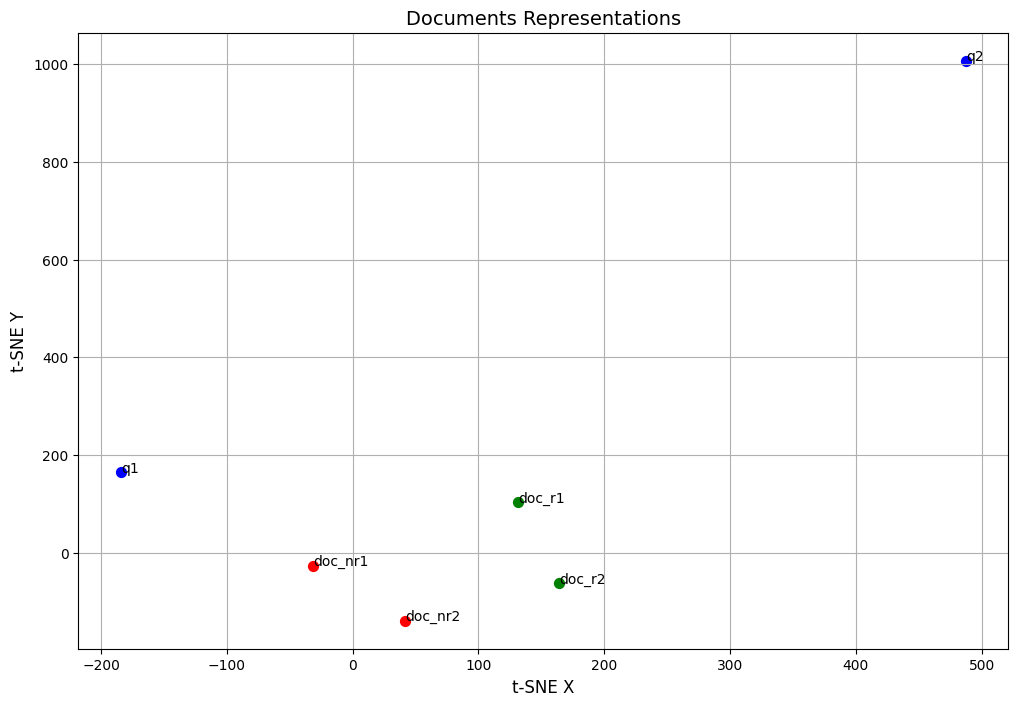

In [38]:
plot_doc_points([q_1, doc_rel_1, doc_nrel_1], [q_2, doc_rel_2, doc_nrel_2], tfidf_2d)

#### b) Word embedding


####  Question ✍


This function computes the averaged representation from all words in the document.

In [39]:
def get_document_word_embedding(doc, model):
    """
    The averaged representation from all words in the document is defined as follows
    we will do the sum of all the embeddings and then divide by the number of words
    """
    emb_list = []
    for word in doc.split():
      word_embedding = get_w2v_vector(word,model)
      if isinstance(word_embedding, str) and word_embedding == "Not in vocabulary": continue
      emb_list.append( np.asarray(word_embedding))
    if len(emb_list) == 0: return np.zeros(model.vector_size)
    return np.nanmean(emb_list, axis=0)




In [40]:
# Convert each document to a vector
word_embeddings_representations = [get_document_word_embedding(doc, w2v_model) for doc in my_mini_corpus]



In [41]:
# Perform t-SNE to reduce dimensions to 2D
tsne_w2v = TSNE(perplexity=15, n_components=2, init='pca', n_iter=2000, random_state=42)
w2v_2d = tsne_w2v.fit_transform(np.array(word_embeddings_representations))  # Transpose to work with word vectors

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


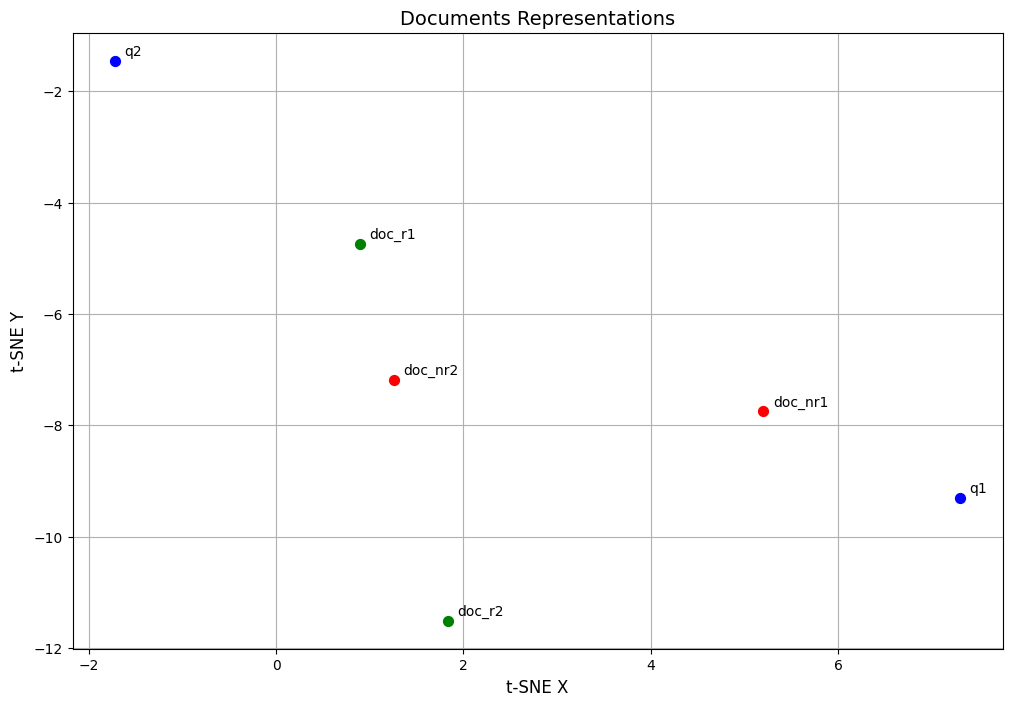

In [42]:
plot_doc_points([q_1, doc_rel_1, doc_nrel_1], [q_2, doc_rel_2, doc_nrel_2], w2v_2d)

#### b) Transformers-based encodings

In [43]:
# Convert each document to its CLS token embedding
document_embeddings = enc_model.encode(my_mini_corpus)

In [44]:
# Perform t-SNE to reduce dimensions to 2D
tsne_enc = TSNE(perplexity=15, n_components=2, init='pca', n_iter=2000, random_state=42)
enc_2d = tsne_enc.fit_transform(np.array(document_embeddings))  # Transpose to work with word vectors

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


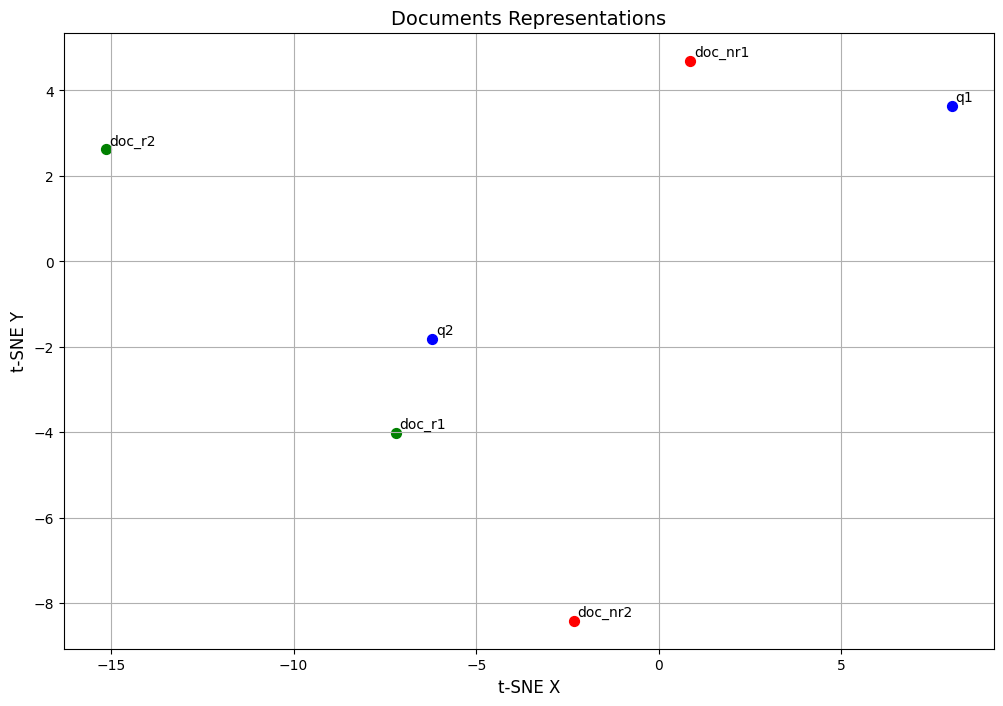

In [45]:
plot_doc_points([q_1, doc_rel_1, doc_nrel_1], [q_2, doc_rel_2, doc_nrel_2], enc_2d)

####  Question ✍

Documents can be very long and one better way is to split them into passages (or paragraphs, chunks). In this section, we ask you to split the documents into passages, and then build the vector semantics of these passages using the previous implementations.


Do the representations change? Justify your answer.

**Answer**:

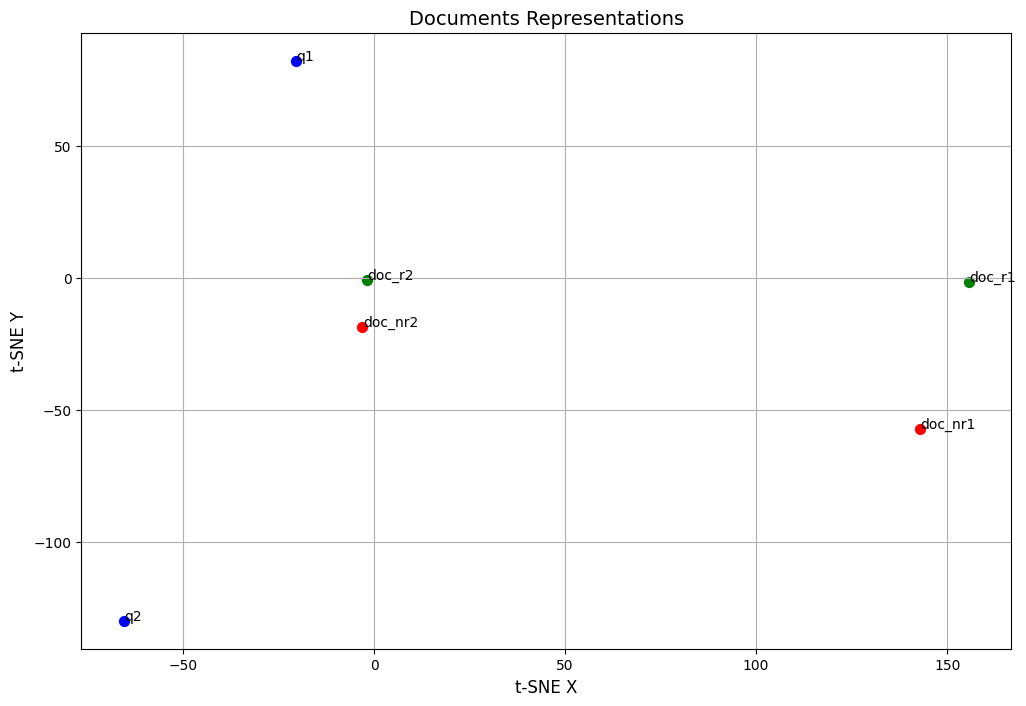

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


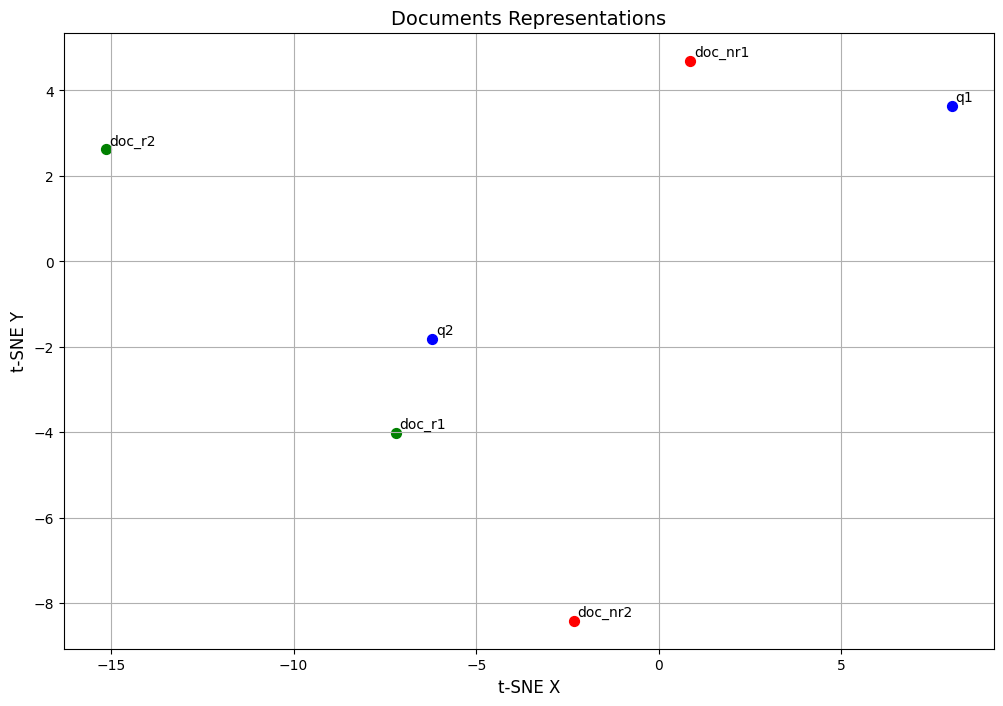

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


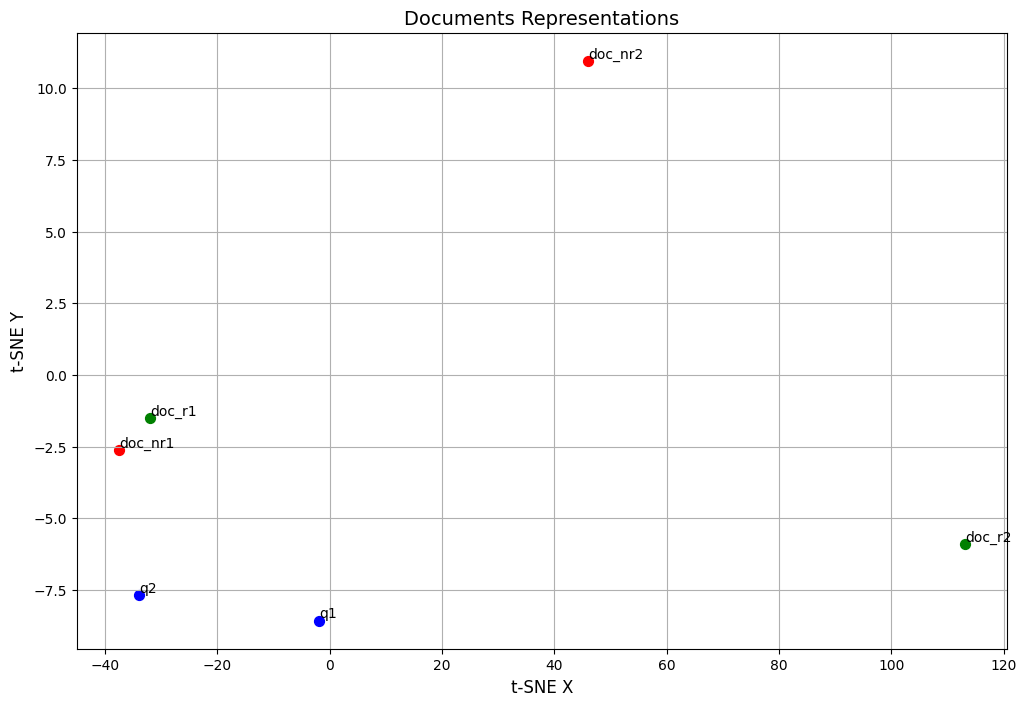

In [46]:
#### Your code here

# Follow the steps:
# 1. Implement the code to split the documents into passages (chunks). One
# naive way is to spit them into phrases. You can then concatenate 5 phrases
# to build one passage. You can propose other methods too.
def document_to_chunks(doc):
  phrases = doc.split(".")
  chunks = []
  while len(phrases) != 0:
    rest = 5 if len(phrases) >= 5 else len(phrases)
    chunks.append( phrases[:rest] )
    phrases = phrases[rest:]
  return chunks



my_passage_corpus = [ passage for doc in my_mini_corpus for passages in document_to_chunks(doc) for passage in passages ]

# 2. Represent TF-IDF vector semantics of passages.
# In order to do so we must compute once again the TF-IDF matrix with the
# passages this time instead of documents

passages_vectorizer, tfidfmatrix_passages = get_tfidf_representations(my_passage_corpus)
tfidf_matrix_array = tfidfmatrix_passages.toarray()
tf_idf_v1 = tfidf_matrix_array[doc_rel_1]
tf_idf_v2 = tfidf_matrix_array[doc_nrel_1]
tf_idf_v3 = tfidf_matrix_array[q_1]

tf_idf_v4 = tfidf_matrix_array[doc_rel_2]
tf_idf_v5 = tfidf_matrix_array[doc_nrel_2]
tf_idf_v6 = tfidf_matrix_array[q_2]

tsne_tfidf = TSNE(n_components=2, random_state=42, perplexity=5, init='random', learning_rate=200)
tfidf_2d = tsne_tfidf.fit_transform(tfidf_matrix_array)

plot_doc_points([q_1, doc_rel_1, doc_nrel_1], [q_2, doc_rel_2, doc_nrel_2], tfidf_2d)

#represent_tfidf_vector(passages_vectorizer, tfidfmatrix_passages)

# 3. Represent Word Embeddings vector semantics of passages.

passage_embeddings_representations = [get_document_word_embedding(doc, w2v_model) for doc in my_passage_corpus]
# Perform t-SNE to reduce dimensions to 2D
tsne_w2v = TSNE(perplexity=15, n_components=2, init='pca', n_iter=2000, random_state=42)
w2v_2d = tsne_w2v.fit_transform(np.array(word_embeddings_representations))  # Transpose to work with word vectors

plot_doc_points([q_1, doc_rel_1, doc_nrel_1], [q_2, doc_rel_2, doc_nrel_2], enc_2d)

# 4. Represent Transformer-based encoders vector semantics of passages.

document_embeddings = enc_model.encode(my_passage_corpus)

# To 2D
tsne_enc = TSNE(perplexity=15, n_components=2, init='pca', n_iter=2000, random_state=42)
enc_2d = tsne_enc.fit_transform(np.array(document_embeddings))

plot_doc_points([q_1, doc_rel_1, doc_nrel_1], [q_2, doc_rel_2, doc_nrel_2], enc_2d)



# II. Question Answering (QA): use embeddings to rank relevant documents that contain the query answer

In this part of the PW, we will use the ``cosine similarity`` to measure how similar each document is to a given query. Cosine similarity calculates the angle between two vectors in space, which helps us understand how closely related they are.

In the previous dataset, there was only one document per query, which was useful for visualization. Now, we will work with a larger dataset that has multiple documents for each query (or question). For each query, we will compare it to all the documents and calculate their similarity using cosine similarity.

Once we have these similarity scores, we will focus on the most relevant documents by selecting the top 1000 documents that are most similar to each query. This helps us identify the documents most likely to contain relevant information for answering the query.

To evaluate the quality of our document retrieval, we will also compare how well the representations perform in identifying relevant documents. Specifically, we will use metrics such as **precision** and **recall** (see your course). These metrics allow us to measure the accuracy and completeness of our document selection. We can calculate precision and recall because we have the ground truth for our task (also called gold answers), meaning we know which documents are truly relevant for each query.

In [47]:
# We load a bigger version of the dataset
covid_set = datasets.load_dataset('jeslev/trec_covid_toyset_pair')
# Then we select the information relevant for our task.
# We're just putting together the documents (research papers) in corpus_test_text
# and the question in queries_test_text
# and their corresponding IDs

README.md:   0%|          | 0.00/859 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

data/qrels_test-00000-of-00001.parquet:   0%|          | 0.00/830k [00:00<?, ?B/s]

data/corpus_test-00000-of-00001.parquet:   0%|          | 0.00/5.97M [00:00<?, ?B/s]

data/queries_test-00000-of-00001.parquet:   0%|          | 0.00/3.95k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/21936 [00:00<?, ? examples/s]

Generating qrels_test split:   0%|          | 0/66336 [00:00<?, ? examples/s]

Generating corpus_test split:   0%|          | 0/8019 [00:00<?, ? examples/s]

Generating queries_test split:   0%|          | 0/20 [00:00<?, ? examples/s]

In [48]:
goldset = covid_set['qrels_test'].to_pandas() # contains the true results
corpus_test_text = list(covid_set['corpus_test'].to_pandas()['document'].values)
corpus_test_ids = list(covid_set['corpus_test'].to_pandas()['corpus-id'].values)
queries_test_text = list(covid_set['queries_test'].to_pandas()['text'].values)
queries_test_ids = list(covid_set['queries_test'].to_pandas()['query-id'].values)
print("Queries IDs in test", queries_test_ids)

Queries IDs in test [np.int64(1), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(11), np.int64(14), np.int64(21), np.int64(22), np.int64(24), np.int64(27), np.int64(31), np.int64(32), np.int64(34), np.int64(37), np.int64(40), np.int64(43), np.int64(47), np.int64(48), np.int64(50)]


In [49]:
# This function computes the cosine similarity between all given queries and document vectors
# Then, it sorts them according to the similarity score and filter the top-1000
def get_top_1000_docs(queries_vec, corpus_vec, queries_test_ids, corpus_test_ids):
    similarity_matrix = cosine_similarity(queries_vec, corpus_vec)

    # Create a DataFrame for results
    results = []
    for i, q_id in enumerate(queries_test_ids):
        for j, d_id in enumerate(corpus_test_ids):
            results.append((q_id, d_id, similarity_matrix[i, j]))

    df = pd.DataFrame(results, columns=["id_q", "id_d", "score"])
    top_1000 = (
        df.sort_values(["id_q", "score"], ascending=[True, False])
        .groupby("id_q")
        .head(1000)
    )
    return top_1000

In [50]:
# These functions compute precision and recall for an specific query-id

def compute_precision(results_df, q_id, gold_df):
    documents_list = set(results_df[results_df['id_q']==q_id]['id_d'].values)
    golden_list = set(gold_df[(gold_df['query-id']==q_id)&(gold_df['score']==2)]['corpus-id'].values)
    correct_predictions = len(documents_list.intersection(golden_list))

    return correct_predictions/len(documents_list)

def compute_recall(results_df, q_id, gold_df):
    documents_list = set(results_df[results_df['id_q']==q_id]['id_d'].values)
    golden_list = set(gold_df[(gold_df['query-id']==q_id)&(gold_df['score']==2)]['corpus-id'].values)
    correct_predictions = len(documents_list.intersection(golden_list))
    return correct_predictions/len(golden_list)

In [51]:
# We create a single corpus (question and documents) to learn the TF-IDF representations
my_corpus = corpus_test_text + queries_test_text
id_max_corpus = len(corpus_test_text)
print("Total elements in corpus", len(my_corpus))

Total elements in corpus 8039


## QA using TF-IDF representations

In [52]:
# Obtain representation (TF-IDF)
tdidf_representations, tfidf_matrix = get_tfidf_representations(my_corpus)
corpus_tfidf, queries_tfidf = tfidf_matrix[:id_max_corpus], tfidf_matrix[id_max_corpus:]

In [53]:
# Compute top-1000 most similar documents per query
results_tfidf = get_top_1000_docs(queries_tfidf, corpus_tfidf, queries_test_ids, corpus_test_ids)

In [54]:
# We can compute the precision and recall for a specific query id
print(f"For question ID: 1 - precision: {compute_precision(results_tfidf, 1, goldset ):.4f}, recall: {compute_recall(results_tfidf, 1, goldset ):.4f}")
print(f"For question ID: 50 - precision: {compute_precision(results_tfidf, 50, goldset ):.4f}, recall: {compute_recall(results_tfidf, 50, goldset ):.4f}")

For question ID: 1 - precision: 0.1000, recall: 0.3279
For question ID: 50 - precision: 0.0360, recall: 0.7660


####  Question ✍

Compute an averaged precision and recall considering all queries

**Answer**:

In [55]:
# Compute an average precision and recall considering all queries
def compute_average_and_recall(results):

  query_precision = [ compute_precision(results, id, goldset) for id in queries_test_ids ]
  query_recall = [ compute_recall(results, id, goldset) for id in queries_test_ids ]
  avg_precision = np.asarray(query_precision).mean()
  avg_recall = np.asarray(query_recall).mean()

  return avg_precision, avg_recall

avg_precision, avg_recall = compute_average_and_recall(results_tfidf)
print(f"Average precision: {avg_precision:.4f}")
print(f"Average recall: {avg_recall:.4f}")


Average precision: 0.1652
Average recall: 0.6105


## QA using Word embeddings representations

####  Question ✍
Complete the code below

In [56]:
# Obtain representation (Word embeddings)
word_embeddings_representations = [ get_document_word_embedding(doc, w2v_model) for doc in my_corpus]
corpus_w2v, queries_w2v = word_embeddings_representations[:id_max_corpus], word_embeddings_representations[id_max_corpus:]

In [57]:
for i in corpus_w2v:
  if not isinstance(i, np.ndarray):
    print(i)

In [58]:
results_w2v = get_top_1000_docs(queries_w2v, corpus_w2v, queries_test_ids, corpus_test_ids )

In [59]:
print(f"For question ID: 1 - precision: {compute_precision(results_w2v, 1, goldset ):.4f}, recall: {compute_recall(results_w2v, 1, goldset ):.4f}")
print(f"For question ID: 50 - precision: {compute_precision(results_w2v, 50, goldset ):.4f}, recall: {compute_recall(results_w2v, 50, goldset ):.4f}")

For question ID: 1 - precision: 0.1150, recall: 0.3770
For question ID: 50 - precision: 0.0370, recall: 0.7872


####  Question ✍

Compute an averaged precision and recall considering all queries

**Answer**:

In [60]:
avg_precision, avg_recall = compute_average_and_recall(results_w2v)

print(f"Average precision: {avg_precision:.4f}")
print(f"Average recall: {avg_recall:.4f}")

Average precision: 0.1414
Average recall: 0.4962


## QA using Transformer-based representations

In [61]:
# Obtain representation (Transformers-based encoders)
document_embeddings = enc_model.encode(my_corpus)
corpus_enc, queries_enc = document_embeddings[:id_max_corpus], document_embeddings[id_max_corpus:]

In [62]:
results_enc = get_top_1000_docs(queries_enc, corpus_enc, queries_test_ids, corpus_test_ids)

In [63]:
print(f"For question ID: 1 - precision: {compute_precision(results_enc, 1, goldset )}, recall: {compute_recall(results_enc, 1, goldset )}")
print(f"For question ID: 50 - precision: {compute_precision(results_enc, 50, goldset )}, recall: {compute_recall(results_enc, 50, goldset )}")

For question ID: 1 - precision: 0.12, recall: 0.39344262295081966
For question ID: 50 - precision: 0.032, recall: 0.6808510638297872


#### Question ✍

Compute an averaged precision and recall considering all queries

**Answer**:

In [64]:
### Your code here
avg_precision, avg_recall = compute_average_and_recall(results_enc)

print(f"Transformer Average precision: {avg_precision:.4f}")
print(f"Transformer Average recall: {avg_recall:.4f}")

Transformer Average precision: 0.1913
Transformer Average recall: 0.6967


####  Question ✍

1. Compare the overall (averaged) performance among the three methods. Which one gives the best results? Why?

**Answer**:

The results computed for TF-IDF matrix, Vector Embeddings and Transformers are the following:

TF-IDF:
- Average precision: 0.1652
- Average recall: 0.6105

Word Embeddings with w2v:
- Average precision: 0.1414
- Average recall: 0.4962

Transformer:
- Transformer Average precision: 0.2239
- Transformer Average recall: 0.8243

We can clearly see that the best results are given by the trasformer architecture. This can be explained by the caracteristic contextual embeddings used in transformers.

2. Identify the **hardest questions**, those with lower scores, and the **easiest questions** those with highest scores, for each method. Are there common identified questions among the methods?

**Answer**:

As a reminder here is the definition of Accuracy (precision) and recall.
The accuracy or precision is a metric that evaluates the correct classifications overall. This can lead to a 99 % accuracy when we are searching for a rare eventment (1 in 100) and that it wasn't classified correcly. This would mean our model is wrong having 99% accuracy.

$$\text{Accuracy} = \frac{\text{correct classifications}}{\text{total classifications}}$$

 The Recall or True Positive Rate metric solves this problem. Allowing us to evaluate the correct classified object over actual possitives. This means that we are evaluating the correct classifications over all the actual occurences of said event we want to classify.
$$\text{Recall (or TPR)} = \frac{\text{correctly classified actual positives}}{\text{all actual positives}}$$




In [105]:
#### Your code here

# To answer the second question we have to compare the scores of the
# each document related to each query in our corpus.
# We will then take the max from each document value
# We will use the function get_top_1000_docs as inspiration
def find_hardest_easiest_question(queries_vec, corpus_vec, queries_test_ids, corpus_test_ids):
  """
  A question is hardest when it has the lower score
  A question is the easiest when it has the highest score
  returns: hardest, easiest questions
  """

  similarity_matrix = cosine_similarity(queries_vec, corpus_vec)
  # Create a DataFrame for results

  results = []
  for i, q_id in enumerate(queries_test_ids):
      for j, d_id in enumerate(corpus_test_ids):

          results.append((q_id, i, d_id, similarity_matrix[i, j]))

  df = pd.DataFrame(results, columns=["id_q", "query_index", "id_d", "score"])
  max_values = ( df.groupby("id_q")
  .max()
  .sort_values(["score"], ascending=[False])
  )
  print(max_values)



  return max_values.tail(1), max_values.head(1)

# TF-IDF
hardest, easiest = find_hardest_easiest_question(queries_tfidf, corpus_tfidf, queries_test_ids, corpus_test_ids)

print(f"TF-IDF Hardest query: {hardest.index[0]} {queries_test_text[hardest['query_index'].array[0]]}, \nTF-IDF Easiest Query: {easiest.index[0]} {queries_test_text[easiest['query_index'].array[0] ]} " )

# Embeddings
hardest, easiest = find_hardest_easiest_question(queries_w2v, corpus_w2v, queries_test_ids, corpus_test_ids )

print(f"TF-IDF Hardest query: {hardest.index[0]} {queries_test_text[hardest['query_index'].array[0]]}, \nTF-IDF Easiest Query: {easiest.index[0]} {queries_test_text[easiest['query_index'].array[0] ]} " )


# Transformers
hardest, easiest = find_hardest_easiest_question(queries_enc, corpus_enc, queries_test_ids, corpus_test_ids)

print(f"TF-IDF Hardest query: {hardest.index[0]} {queries_test_text[hardest['query_index'].array[0]]}, \nTF-IDF Easiest Query: {easiest.index[0]} {queries_test_text[easiest['query_index'].array[0] ]} " )




      query_index      id_d     score
id_q                                 
1               0  zzxdg5zo  0.597419
22              8  zzxdg5zo  0.576883
50             19  zzxdg5zo  0.526158
14              6  zzxdg5zo  0.524919
9               4  zzxdg5zo  0.503888
7               3  zzxdg5zo  0.428393
40             15  zzxdg5zo  0.370038
6               2  zzxdg5zo  0.367849
24              9  zzxdg5zo  0.365586
32             12  zzxdg5zo  0.351744
37             14  zzxdg5zo  0.346487
48             18  zzxdg5zo  0.335270
21              7  zzxdg5zo  0.326651
27             10  zzxdg5zo  0.322611
47             17  zzxdg5zo  0.321411
5               1  zzxdg5zo  0.309583
11              5  zzxdg5zo  0.303866
43             16  zzxdg5zo  0.290103
34             13  zzxdg5zo  0.270370
31             11  zzxdg5zo  0.263080
TF-IDF Hardest query: 31 How does the coronavirus differ from seasonal flu?, 
TF-IDF Easiest Query: 1 what is the origin of COVID-19 
      query_index      id_d   

The results show that there are not any common hardest or easiest question. However if we focus on the overall result we can see that some question are placed in the same position throughout all the 3 methods. By example q_id 22. Questions such as question 9 seem to be close to hardest in the embedding and transformers method. But they are in the top 5 easiest questions using TF-IDF.

# III. Pipeline Retrieve-Re-rank: Improving previous ranking methods

In this section, we will apply a **re-ranking** approach to improve the retrieval of relevant documents for a given query (see your course). The idea is to combine in sequence the strengths of two methods: 1) first stage we will use previous methods (TF-IDF,  word embeddings) to retrieve and rank the top-1000 most relevant documents; 2) second stage, we will apply an encoder-based model to **re-rank** these documents, refining the relevance score for each document.

This approach is particularly useful because running large encoder models on every document in a large collection can be computationally expensive. By first narrowing down the pool of documents with the more efficient methods, we reduce the number of documents that need to be processed by the encoder model.

To evaluate the effectiveness of this re-ranking process, we will use the **Mean Reciprocal Rank (MRR)** metric. MRR is sensitive to the position of the relevant document in the ranking, meaning it gives a higher score when the relevant document appears earlier in the list of results (see your course). This will allow us to compare the performance of the system both with and without re-ranking, and see how well our method performs in bringing relevant documents to the top.

Before performing re-ranking, we first need to **fine-tune** an encoder model on our specific dataset. This model, trained on our collection of queries and documents, will capture the nuances of the data and be able to better rank documents based on their relevance to a query. Once fine-tuned, this encoder model will be used to reorder the top-1000 documents identified by the earlier methods, improving the quality of the final rankings.

Execute the following code to fine-tune the model in our collection

In [96]:
# Code to fine-tune a Transformer for ranking

# Prepare the dataset
df_train = covid_set['train'].to_pandas()

# Step 1: Filter documents with scores 0 (negatives) and 2 (positives)
df_positive = df_train[df_train["score"] == 2].copy()
df_negative = df_train[df_train["score"] == 0].copy()

# Step 2: Group documents by query
positive_group = df_positive.groupby("text")
negative_group = df_negative.groupby("text")


new_dataset = []

for query, pos_docs in positive_group:
    # Get positive documents
    doc_pos_list = pos_docs["document"].tolist()

    # Get corresponding negative documents
    if query in negative_group.groups:
        neg_docs = negative_group.get_group(query)["document"].tolist()
    else:
        neg_docs = []

    # Add rows to the new dataset
    for doc_pos in doc_pos_list:
        for doc_neg in neg_docs:
            new_dataset.append({"query": query, "doc_pos": doc_pos, "doc_neg": doc_neg})
new_df = pd.DataFrame(new_dataset)


# We use only a subsample to run it fast
df_to_train = new_df.sample(n=5000)
from datasets import Dataset
train_dataset = Dataset.from_pandas(df_to_train)
train_dataset = train_dataset.remove_columns(['__index_level_0__'])


# We setup the model
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
    SentenceTransformerModelCardData,
)
from sentence_transformers.losses import MultipleNegativesRankingLoss
from sentence_transformers.training_args import BatchSamplers
from sentence_transformers.evaluation import TripletEvaluator

# Load a model to finetune
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

#  Load a dataset to finetune on
# Why is this step necessary ?
train_dataset = train_dataset
#  Define a loss function
loss = MultipleNegativesRankingLoss(model)



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [97]:
#  Specify training arguments
args = SentenceTransformerTrainingArguments(
    # Required parameter:
    output_dir="my_ft_model",
    # Optional training parameters:
    num_train_epochs=1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=1e-5,
    warmup_ratio=0.1,
    #fp16=True,  # Set to False if you get an error that your GPU can't run on FP16
    bf16=False,  # Set to True if you have a GPU that supports BF16
    batch_sampler=BatchSamplers.NO_DUPLICATES,  # MultipleNegativesRankingLoss benefits from no duplicate samples in a batch
    # Optional tracking/debugging parameters:
    save_strategy="epoch",
    save_steps=1,
    save_total_limit=2,
    logging_steps=100,
    report_to="none",
)

# Create a trainer & train
trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    loss=loss,
)
trainer.train()
# Save the trained model
model.save_pretrained("my_ft_model/final")

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
100,0.917273
200,0.630767
300,0.630818
400,0.579841
500,0.435954
600,0.593046
700,0.517343
800,0.506292
900,0.482869
1000,0.483844


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Now, we compute the vector representations of our questions and documents using this improved model.

Before performing re-ranking, we can also evaluate the performance of this model in our questions (since it is a small dataset).

We can observe that scores improved the ``pre-trained`` version of this encoder, showing the effect of finetuning for this task

In [106]:
# Obtain representation (Transformers-based encoders)
document_embeddings = embeddings = model.encode(my_corpus)
corpus_enc, queries_enc = document_embeddings[:id_max_corpus], document_embeddings[id_max_corpus:]

In [107]:
results_enc = get_top_1000_docs(queries_enc, corpus_enc, queries_test_ids, corpus_test_ids)

In [108]:
print(f"For question ID: 1 - precision: {compute_precision(results_enc, 1, goldset )}, recall: {compute_recall(results_enc, 1, goldset )}")
print(f"For question ID: 50 - precision: {compute_precision(results_enc, 50, goldset )}, recall: {compute_recall(results_enc, 50, goldset )}")

For question ID: 1 - precision: 0.225, recall: 0.7377049180327869
For question ID: 50 - precision: 0.042, recall: 0.8936170212765957


In [110]:
def compute_mrr(results_df, q_id, gold_df):
    """
    Computes Mean Reciprocal Rank (MRR) for a given query.
    Returns:
        float: The MRR score.
    """
    pred = set(results_df[results_df['id_q']==q_id]['id_d'].values)
    golden_list = set(gold_df[(gold_df['query-id']==q_id)&(gold_df['score']==2)]['corpus-id'].values)

    rank = 0
    for idx, doc_id in enumerate(pred, start=1):
        if doc_id in golden_list:  # Check if the predicted doc_id is relevant
            rank = 1 / idx
            break # Why do we put a break in here ? Should'nt we do the MRR for every occurence ?

    return rank


## Rank with TF-IDF model then Re-rank with a BERT-based encoder


In [111]:
# We recover the test set information
df_corpus = covid_set['corpus_test'].to_pandas()
df_queries = covid_set['queries_test'].to_pandas()

# We extend our TF-IDF results with the corresponding text for query and document
df_extended = pd.merge(results_tfidf, df_corpus[['corpus-id', 'document']],
    left_on='id_d', right_on='corpus-id', how='left')
df_extended.drop(columns=['corpus-id'], inplace=True)
df_extended = pd.merge(df_extended, df_queries[['query-id', 'text']],  # Select only necessary columns
    left_on='id_q', right_on='query-id', how='left')
df_extended.drop(columns=['query-id'], inplace=True)

print(df_extended.head())


   id_q      id_d     score  \
0     1  dv9m19yk  0.597419   
1     1  1g2mup0k  0.437013   
2     1  aqbcq8rs  0.421628   
3     1  pl48ev5o  0.419633   
4     1  h8ahn8fw  0.419633   

                                            document  \
0  [What is the origin of SARS-CoV-2?] Every time...   
1         COVID-19: what is next for public health?    
2      Covid-19: What is the UK's testing strategy?    
3  Origin and evolution of the 2019 novel coronav...   
4  Origin and Evolution of the 2019 Novel Coronav...   

                             text  
0  what is the origin of COVID-19  
1  what is the origin of COVID-19  
2  what is the origin of COVID-19  
3  what is the origin of COVID-19  
4  what is the origin of COVID-19  


In [113]:
# Then, we compute the similarity of the pair (query, document) from the results tf-idf
embeddings1 = model.encode(list(df_extended['document'].values))
embeddings2 = model.encode(list(df_extended['text'].values))


# Compute cosine similarities
similarities = []
for emb1, emb2 in zip(embeddings1, embeddings2):
    similarities.append(float(model.similarity(emb1, emb2)[0]))

df_extended['new_score'] = similarities

new_top_1000 = (
    df_extended.sort_values(["id_q", "new_score"], ascending=[True, False])
    .groupby("id_q")
    .head(1000)
)

In [121]:
# We compute the MRR score using this approach

print(f"For question ID: 1 - MRR: {compute_mrr(new_top_1000, 1, goldset ):.4f}")
print(f"For question ID: 50 - MRR: {compute_mrr(new_top_1000, 50, goldset ):.4f}")

For question ID: 1 - MRR: 0.1250
For question ID: 50 - MRR: 0.1667


#### Question ✍

Compute an averaged MRR considering all queries. Compare the MRR scores between the simple TF-IDF model and with the re-ranking approach

Interpret the results

**Answer**:

Before computing the averaged MRR we will define what Mean Reciprocal Rank is and what are it's metrics are:

$$RR@(k) = \begin{cases} \frac{1}{rank(j)} & \text{if } rank(j) \leq k \\ 0 & \text{otherwise} \end{cases}$$

$$MRR@k = \frac{1}{|Q|} RR@(k)$$

A Reciprocal Rank refers to the inverse of the first relevant element to appear ${ \frac{1}{rank(j)} }$. We just have to do the compute of said RR with ${|Q|}$ being the total number of queries. In our specific case knowing that we are computing the MRR for a specific query. We aren't actually computing the Mean. This means that we are actually just computing the RR in MRR.

In [141]:
#### Your code here
def compute_averaged_mrr( results_df,  goldset ):
    averaged_mrr = [ compute_mrr(results_df, q_id, goldset) for q_id in corpus_test_ids ]
    return np.mean(averaged_mrr, axis=None)

# Simple TF-IDF scores
print(results_tfidf.groupby('id_q').head(1))
print("==========================================")
# New Reranked scores
print(new_top_1000.groupby('id_q').head(1))

print(f"Average MRR : {compute_averaged_mrr(new_top_1000, goldset)}")


        id_q      id_d     score
2861       1  dv9m19yk  0.597419
14052      5  dqour5jr  0.309583
16815      6  aqbcq8rs  0.367849
28164      7  xp7ole0u  0.428393
34899      9  pi0rmaot  0.503888
44545     11  o115igdw  0.303866
49187     14  na3vrf5q  0.524919
61822     21  2vxnmiyj  0.326651
69145     22  wkp58iov  0.576883
73121     24  6duc06et  0.365586
80627     27  ls6cdive  0.322611
89082     31  k1fx7xvb  0.263080
101543    32  1sbnewog  0.351744
111974    34  dvg0isgt  0.270370
115248    37  oi2cm546  0.346487
122675    40  ttbur07i  0.370038
134818    43  tydil7d7  0.290103
141113    47  1g2mup0k  0.321411
147374    48  7yxz43c6  0.335270
152571    50  bchcy4hn  0.526158
       id_q      id_d     score  \
14        1  u7u75sl0  0.338860   
1009      5  jbc74lcu  0.272197   
2127      6  cjk0ggkt  0.153730   
3000      7  xp7ole0u  0.428393   
4169      9  v346cpkl  0.096443   
5300     11  tkxsvybh  0.099761   
6000     14  na3vrf5q  0.524919   
7235     21  lizwiate  0.13

When comparing the data between the TF-IDF model and the re-ranked model we can clearly see that the scores have improved. And that in some cases some document that seemed not to be that related to the query have now the highest similarity score. The MRR calculated was 0. Meaning that the most relevant object is always at the bottom

## Rank with Word embeddings then Re-rank with BERT-based encoder

#### Question ✍

Implement the re-ranking approach using the Word Embedding results from the previous section

In [142]:
#### Your code here
# Since the computing of the embeddings is already done we only have to do the
# expanding of our dataset and then the re-rank

# We recover the test set information
df_corpus = covid_set['corpus_test'].to_pandas()
df_queries = covid_set['queries_test'].to_pandas()

# We extend our TF-IDF results with the corresponding text for query and document
df_extended = pd.merge(results_w2v, df_corpus[['corpus-id', 'document']],
    left_on='id_d', right_on='corpus-id', how='left')
df_extended.drop(columns=['corpus-id'], inplace=True)
df_extended = pd.merge(df_extended, df_queries[['query-id', 'text']],  # Select only necessary columns
    left_on='id_q', right_on='query-id', how='left')
df_extended.drop(columns=['query-id'], inplace=True)

print(df_extended.head())



   id_q      id_d     score  \
0     1  dv9m19yk  0.824880   
1     1  hmvo5b0q  0.740996   
2     1  o385cvpp  0.706871   
3     1  v0vjkwy9  0.705528   
4     1  s9dy7iyf  0.705528   

                                            document  \
0  [What is the origin of SARS-CoV-2?] Every time...   
1  Understanding Coronavirus Since the identifica...   
2  Complexities of difference and their significa...   
3  COVID-19 Super-spreaders: Definitional Quandar...   
4  COVID-19 Super-spreaders: Definitional Quandar...   

                             text  
0  what is the origin of COVID-19  
1  what is the origin of COVID-19  
2  what is the origin of COVID-19  
3  what is the origin of COVID-19  
4  what is the origin of COVID-19  


In [143]:
# re-ranking
embeddings1 = model.encode(list(df_extended['document'].values))
embeddings2 = model.encode(list(df_extended['text'].values))


# Compute cosine similarities
similarities = []
for emb1, emb2 in zip(embeddings1, embeddings2):
    similarities.append(float(model.similarity(emb1, emb2)[0]))

df_extended['new_score'] = similarities

# Re-ranking
new_top_1000 = (
    df_extended.sort_values(["id_q", "new_score"], ascending=[True, False])
    .groupby("id_q")
    .head(1000)
)

#### Question ✍

Compute an averaged MRR considering all queries. Compare the MRR scores between the simple Word embedding model and with the re-ranking approach

Interpret the results

**Answer**:

In [144]:
# Simple embeddings scores
print(results_w2v.groupby('id_q').head(1))
print("==========================================")
print(new_top_1000.groupby('id_q').head(1))

print(f"Average MRR : {compute_averaged_mrr(new_top_1000, goldset)}")


        id_q      id_d     score
2861       1  dv9m19yk  0.824880
15860      5  vyeescn8  0.791468
20565      6  rhmywn8n  0.813352
30817      7  3g75spkc  0.832571
34555      9  gz70hd7d  0.686458
43523     11  m8iqens3  0.822936
49187     14  na3vrf5q  0.780343
58756     21  632r6uqe  0.861830
66856     22  qbxx6yae  0.881522
75721     24  hycd9zua  0.802457
82408     27  7hqn997j  0.819993
88796     31  2dw318eg  0.770997
96864     32  j6lbxlm3  0.831292
107320    34  mcrf27ew  0.765669
117069    37  u79ncd4s  0.818200
122583    40  2b25p7t7  0.859373
128979    43  miem1poh  0.779920
137587    47  b4r0jyjo  0.766659
147838    48  wbl2hg7d  0.805718
156989    50  0razl9qf  0.796016
       id_q      id_d     score  \
688       1  u7u75sl0  0.604639   
1009      5  jbc74lcu  0.766356   
2445      6  rk8pract  0.716143   
3209      7  mhseqwi3  0.772377   
4003      9  v346cpkl  0.639359   
5031     11  ba5x3ysq  0.789998   
6000     14  na3vrf5q  0.780343   
7086     21  lizwiate  0.79

Contrary to popular belief. The re-ranked results of the embedding model are worse that before. This notes that re-ranking is not a technique usefull for embeddings